# 🚀 Proyecto 001

# Predicción de la Calidad del Espumado mediante Machine Learning

### Caso de estudio aplicado a una línea de producción de bebidas carbonatadas

---

## 👤 Autor

**Civita Gonzalo**

---

## 📅 Fecha

Julio 2023

---

## 📌 Objetivo

Desarrollar un modelo de Machine Learning capaz de predecir el nivel de espumado utilizando variables operativas del proceso productivo, con el propósito de mejorar la calidad del producto, reducir desperdicios y facilitar la toma de decisiones basada en datos.


# 📑 Tabla de Contenidos

1. Comprensión del problema de negocio
2. Objetivos del proyecto
3. Metodología
4. Stack tecnológico
5. Descripción del conjunto de datos
6. Importación de librerías
7. Carga y exploración inicial de los datos
8. Análisis exploratorio de datos (EDA)
9. Preparación de datos
10. Entrenamiento de modelos
11. Evaluación de modelos
12. Impacto para el negocio
13. Simulación de escenario pasado
14. Conclusiones
15. Próximos pasos

# 1️. Comprensión del Problema de Negocio

## Contexto

En la industria de bebidas carbonatadas, el nivel de espumado constituye un indicador crítico de la calidad del proceso de producción. Variaciones en parámetros como la temperatura, la presión, el tipo de endulzante o la velocidad de llenado pueden afectar significativamente el comportamiento del espumado.

Una clasificación incorrecta del nivel de espumado puede generar pérdidas económicas asociadas a reprocesos, desperdicio de materia prima, reducción de la productividad y posibles reclamos de clientes.

En este contexto, la Ciencia de Datos y el Machine Learning permiten desarrollar modelos predictivos capaces de anticipar el comportamiento del proceso y brindar soporte a la toma de decisiones operativas.

# 2️. Objetivos del Proyecto

## Objetivo General

Desarrollar un modelo predictivo que permita clasificar el nivel de espumado utilizando variables operativas del proceso productivo.

## Objetivos Específicos

- Analizar la calidad y estructura del conjunto de datos.
- Identificar las variables con mayor influencia sobre el nivel de espumado.
- Preparar los datos para el entrenamiento de modelos predictivos.
- Construir y comparar diferentes algoritmos de clasificación.
- Seleccionar el modelo con mejor desempeño mediante métricas de evaluación.
- Interpretar los resultados desde una perspectiva técnica y de negocio.
- Proponer oportunidades de mejora para futuras implementaciones.

# 3️. Metodología

Para el desarrollo de este proyecto se seguirá un flujo de trabajo basado en la metodología CRISP-DM, ampliamente utilizada en proyectos de Ciencia de Datos.

Las etapas contempladas son:

- 📌 Comprensión del problema de negocio
- 📊 Comprensión y exploración de los datos
- 🧹 Preparación de los datos
- ⚙️ Ingeniería de características
- 🤖 Entrenamiento de modelos
- 📈 Evaluación del desempeño
- 💼 Interpretación de resultados y conclusiones

# 4️. Stack Tecnológico

| Herramienta | Aplicación |
|-------------|------------|
| 🐍 Python | Desarrollo del proyecto |
| 🐼 Pandas | Manipulación y análisis de datos |
| 🔢 NumPy | Cálculo numérico |
| 📊 Matplotlib | Visualización de datos |
| 🤖 Scikit-Learn | Modelado de Machine Learning |
| ☁️ Google Colab | Desarrollo del notebook |

# 5️. Descripción del Conjunto de Datos

El conjunto de datos contiene información correspondiente a variables operativas registradas durante el proceso de producción de bebidas carbonatadas.

Estas variables serán utilizadas para entrenar modelos de Machine Learning capaces de clasificar el nivel de espumado del producto.

En las siguientes secciones se realizará una exploración inicial del conjunto de datos para comprender su estructura, calidad y distribución.

# 6️. Importación de Librerías

En esta sección se importan las librerías necesarias para el desarrollo del proyecto.

Las herramientas utilizadas permiten realizar tareas de manipulación de datos, visualización, modelado y evaluación de algoritmos de Machine Learning.

In [2]:
'''
# Para Google Colab, montar Google Drive y cargar archivos desde el sistema de archivos local
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Para cargar archivos desde el sistema de archivos local
from google.colab import files
'''

"\n# Para Google Colab, montar Google Drive y cargar archivos desde el sistema de archivos local\nfrom google.colab import drive\ndrive.mount('/content/drive', force_remount=True)\n\n# Para cargar archivos desde el sistema de archivos local\nfrom google.colab import files\n"

In [3]:
# Importamos las librerías necesarias para el proyecto.

from pathlib import Path
import numpy as np  # Para realizar operaciones numéricas y trabajar con arreglos multidimensionales.
import pandas as pd  # Para manipulación y análisis de datos en estructuras DataFrame.
import matplotlib.pyplot as plt  # Para crear gráficos y visualizaciones estáticas.
import matplotlib.cm as cm  # Para trabajar con mapas de color en visualizaciones.
from matplotlib.colors import ListedColormap  # Para crear y manipular mapas de color personalizados.
import matplotlib.patches as mpatches  # Para crear formas y anotaciones en gráficos.
import plotly.express as px  # Para crear gráficos interactivos y sencillos.
import plotly.graph_objs as go  # Para crear gráficos interactivos y personalizables.
import kaleido  # Para exportar gráficos de Plotly a imágenes estáticas.
from plotly.subplots import make_subplots  # Para crear gráficos interactivos con múltiples subgráficos.
from sklearn.preprocessing import StandardScaler  # Para normalizar características eliminando la media y escalando a la varianza unitaria.
from sklearn.tree import DecisionTreeClassifier, export_text  # Para construir modelos de clasificación usando árboles de decisión.
from sklearn.neighbors import KNeighborsClassifier  # Para construir modelos de clasificación basados en K-Nearest Neighbors.
from sklearn.svm import SVC  # Para construir modelos de clasificación usando Máquinas de Soporte Vectorial.
from sklearn.naive_bayes import GaussianNB  # Para construir modelos de clasificación basados en el clasificador Naive Bayes Gaussiano.
from sklearn.metrics import accuracy_score, classification_report  # Para evaluar la precisión y generar informes de clasificación de modelos.
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV  # Para dividir datos en conjuntos de entrenamiento y prueba, validación cruzada y búsqueda de hiperparámetros.
from sklearn.tree import plot_tree  # Para visualizar la estructura de un árbol de decisión.
from sklearn.metrics import confusion_matrix  # Para calcular la matriz de confusión de un modelo de clasificación.
from sklearn.metrics import ConfusionMatrixDisplay  # Para visualizar la matriz de confusión.
from sklearn.neighbors import KNeighborsRegressor  # Para construir modelos de regresión basados en K-Nearest Neighbors.
from sklearn.tree import DecisionTreeRegressor  # Para construir modelos de regresión usando árboles de decisión.
from sklearn.svm import SVR  # Para construir modelos de regresión usando Máquinas de Soporte Vectorial.
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  # Para evaluar el desempeño de modelos de regresión con diferentes métricas.
PROJECT_ROOT = Path("/content/drive/MyDrive/DataScience-Portfolio/project-001-foam-quality-prediction")

import joblib
import json
import warnings
warnings.filterwarnings('ignore')  # Para ignorar las advertencias durante la ejecución del código.


## Configuración del Proyecto

Para facilitar la reproducibilidad del proyecto, se define la ubicación del conjunto de datos mediante rutas relativas utilizando la librería `pathlib`.

Esta práctica permite ejecutar el notebook en diferentes equipos sin modificar el código.

In [4]:
# ==========================================================
# Configuración del proyecto colab
# ==========================================================

#PROJECT_ROOT = Path(
    #"/content/drive/MyDrive/DataScience-Portfolio/project-001-foam-quality-prediction")


# ==========================================================
# Configuración del proyecto
# ==========================================================

# Detectar automáticamente la raíz del proyecto
PROJECT_ROOT = Path.cwd().resolve()

# Si el notebook se ejecuta desde /notebooks,
# subir un nivel hasta la raíz del proyecto
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# ==========================================================
# Directorios principales
# ==========================================================

DATA_DIR = PROJECT_ROOT / "data"

RAW_DATA = DATA_DIR / "raw"
PROCESSED_DATA = DATA_DIR / "processed"
EXTERNAL_DATA = DATA_DIR / "external"

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
EXECUTIVE_DIR = REPORTS_DIR / "executive"

DASHBOARDS_DIR = PROJECT_ROOT / "dashboards"
DOCS_DIR = PROJECT_ROOT / "docs"

# ==========================================================
# Dataset principal
# ==========================================================

DATASET = RAW_DATA / "foam_quality_dataset.xlsx"

# ==========================================================
# Verificación
# ==========================================================

print(f"📁 PROJECT_ROOT: {PROJECT_ROOT}")

if DATASET.exists():
    print(f"✅ Dataset encontrado:\n{DATASET}")
else:
    raise FileNotFoundError(
        f"No se encontró el dataset:\n{DATASET}"
    )

# Carpeta donde se almacenarán las figuras

# ==========================================================
# Carpeta donde se almacenarán las figuras
# ==========================================================

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_plotly_figure(fig, name):
    """
    Guarda una figura Plotly en formato HTML y PNG.
    
    Parámetros
    ----------
    fig : plotly.graph_objects.Figure
        Figura que se desea guardar.
        
    name : str
        Nombre del archivo sin extensión.
    """

    html_path = FIGURES_DIR / f"{name}.html"
    png_path = FIGURES_DIR / f"{name}.png"

    # Guardar versión interactiva
    fig.write_html(html_path)

    # Guardar versión estática
    fig.write_image(png_path)

    print(f"✅ HTML: {html_path}")
    print(f"✅ PNG : {png_path}")

📁 PROJECT_ROOT: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction
✅ Dataset encontrado:
C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\data\raw\foam_quality_dataset.xlsx


# 7. Carga y exploración inicial de los datos

 ¿Cómo está compuesto el conjunto de datos?

In [5]:
# Cargamos el archivo en formato Excel.
df = pd.read_excel(DATASET)

# Copia de trabajo
data = df.copy()

# Muestra la cantidad de filas y columnas y los nombres de dichas columanas.
forma = df.shape
columnas = df.columns
print("\n","Cabtidad de filas y columnas:",forma,"\n\n","Características:",columnas)

# Muestra las primeras filas del DataFrame.
df.head()

# Guardar el DataFrame procesado
df.to_csv(
    PROCESSED_DATA / "foam_quality_dataset_processed.csv",
    index=False
)

print("Dataset procesado guardado correctamente.")


 Cabtidad de filas y columnas: (171, 16) 

 Características: Index(['Fecha', 'Control', 'Producto', 'O2 desaireador', 'O2 cwc',
       'O2 ing carbo', 'Set factor CO2', 'Volumen CO2', 'Temp botella',
       'Temp Carbo', 'Pres bomba', 'Azucar', 'JMAF', 'Sin Azucar',
       'Vel_llenado _botellas/ horas', 'Nivel de espumado'],
      dtype='str')
Dataset procesado guardado correctamente.


# 8. Análisis exploratorio de datos (EDA)

## Objetivo

El Análisis Exploratorio de Datos (EDA) tiene como finalidad comprender la estructura del conjunto de datos, identificar patrones, detectar posibles anomalías y conocer la relación entre las variables antes de construir los modelos de Machine Learning.

Durante esta etapa se responderán diversas preguntas que permitirán comprender mejor el comportamiento del proceso de espumado y facilitarán la toma de decisiones durante las etapas posteriores del proyecto.

In [6]:
# Usamos la caracsterísrica "Control" como indice del DataFrame.
df.set_index(["Control"], inplace = True)


In [7]:
# Muestra un resumen informativo del DataFrame, incluyendo el índice y el tipo
df.info()

<class 'pandas.DataFrame'>
Index: 171 entries, 1 to 163
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Fecha                         171 non-null    datetime64[us]
 1   Producto                      171 non-null    str           
 2   O2 desaireador                171 non-null    float64       
 3   O2 cwc                        171 non-null    float64       
 4   O2 ing carbo                  171 non-null    float64       
 5   Set factor CO2                171 non-null    float64       
 6   Volumen CO2                   171 non-null    float64       
 7   Temp botella                  171 non-null    float64       
 8   Temp Carbo                    171 non-null    float64       
 9   Pres bomba                    171 non-null    float64       
 10  Azucar                        171 non-null    int64         
 11  JMAF                          171 non-null    in

In [8]:
# Muestra las estadísticas descriptivas del DataFrame.
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Fecha,171,2023-12-27 01:49:28.421052,2023-12-01 00:00:00,2023-12-03 00:00:00,2023-12-11 00:00:00,2024-01-22 12:00:00,2024-02-15 00:00:00,NaN
O2 desaireador,171.0,1.457427,0.16,0.31,0.34,2.845,4.3,1.625366
O2 cwc,171.0,1.572924,0.21,0.33,0.36,3.03,4.64,1.740589
O2 ing carbo,171.0,1.59848,0.28,0.41,0.51,3.2,4.64,1.615355
Set factor CO2,171.0,3.724561,3.6,3.7,3.7,3.7,4.0,0.099317
Volumen CO2,171.0,3.943509,3.77,3.89,3.91,3.99,4.27,0.083119
Temp botella,171.0,7.678596,4.8,6.35,7.0,9.1,12.4,1.912075
Temp Carbo,171.0,6.619415,4.0,5.3,6.1,8.0,11.5,1.801
Pres bomba,171.0,4.5,4.5,4.5,4.5,4.5,4.5,0.0
Azucar,171.0,0.678363,0.0,0.0,1.0,1.0,1.0,0.468477


### Interpretación

El conjunto de datos está compuesto por variables numéricas relacionadas con el proceso de producción y una variable objetivo correspondiente al nivel de espumado.

En esta etapa se verifica que la estructura de los datos sea consistente antes de continuar con el análisis exploratorio.



In [9]:
#Eliminamos la columna "Fecha".
df = df.drop('Fecha', axis = 1)

#Eliminamos la columna "Pres bomba" por comsiderarla intrascendente ya que posee el mismo valor para todos los datos recolectados.
df = df.drop(['Pres bomba', 'Producto'], axis = 1)

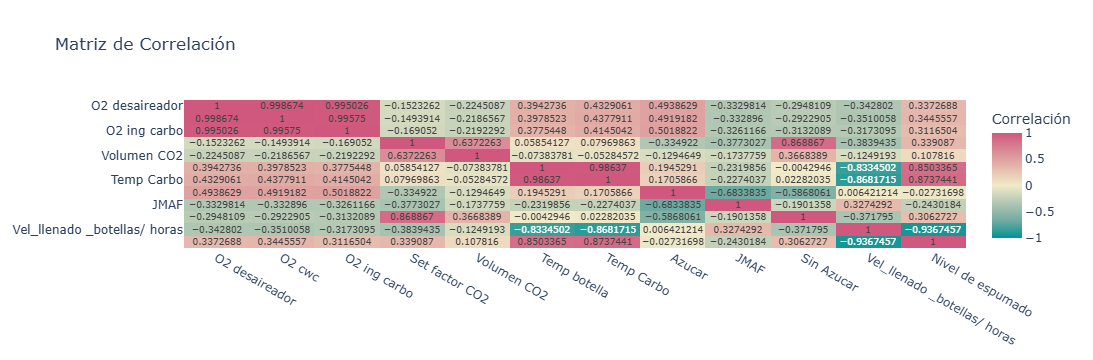

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\correlation_matrix.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\correlation_matrix.png


In [10]:
#Creamos el gráfico de calor para la matriz de correlación
fig = px.imshow(df.corr(),
                text_auto=True,
                aspect="auto",
                title="Matriz de Correlación",
                labels={"color": "Correlación"},
                color_continuous_scale=px.colors.diverging.Tealrose,
                zmin=-1,
                zmax=1)
fig.show()
plt.close()

save_plotly_figure(
    fig,
    "correlation_matrix"
)

### Interpretación

 A través de la matriz de correlación, podemos identificar, mediante el índice de Pearson, ciertos puntos que nos permiten apoyar nuestra hipótesis.

 Identificamos que la temperatura tiene una correlación negativa con respecto a la velocidad de llenado y, aunque en menor medida, el volumen de CO2 y el O2 disuelto en la bebida también.
 Además, podemos observar que los tipos de endulzantes difieren en su relación con la velocidad de llenado.

 El uso de la matriz de correlación y el índice de Pearson es fundamental en la exploración de datos para entender las relaciones entre variables. En este caso, identificar que la temperatura tiene una correlación negativa con la velocidad de llenado puede ser crucial para optimizar procesos industriales, como en la producción de bebidas. La observación de que el volumen de CO2 y el O2 disuelto también tienen alguna influencia, aunque menor, sugiere que hay múltiples factores a considerar para mejorar la eficiencia del llenado.

 La variabilidad en la relación de los tipos de endulzantes con la velocidad de llenado es particularmente interesante, ya que puede implicar diferencias en la viscosidad o en otras propiedades físicas de las soluciones, afectando el proceso de producción. En general, estos hallazgos pueden conducir a ajustes en las condiciones operativas para maximizar la eficiencia y la calidad del producto final. Es un ejemplo claro de cómo el análisis de datos puede tener aplicaciones prácticas y directas en la mejora de procesos industriales.

In [11]:
#Vemos el mínimo y máximo valor de velocidad de llenado por clase.

#Clase_0 = 23500 a 24000 b/h
#Clase_1 = 21000 a 23499 b/h
#Clase_2 = 15500 a 20999 b/h
#Clase_3 = menos de 15499 b/h

niveles_espumado = [0, 1, 2, 3]
resultados = {}

for nivel in niveles_espumado:
    n_espumado = df[df['Nivel de espumado'] == nivel]
    vel_llenado_min = n_espumado['Vel_llenado _botellas/ horas'].min()
    vel_llenado_max = n_espumado['Vel_llenado _botellas/ horas'].max()
    resultados[nivel] = {'min': vel_llenado_min, 'max': vel_llenado_max}

for nivel, valores in resultados.items():
    print(f"Nivel de espumado {nivel}:")
    print(f"Velocidad de llenado mínima: {valores['min']}")
    print(f"Velocidad de llenado máxima: {valores['max']}")



Nivel de espumado 0:
Velocidad de llenado mínima: 23502
Velocidad de llenado máxima: 24071
Nivel de espumado 1:
Velocidad de llenado mínima: 21001
Velocidad de llenado máxima: 23322
Nivel de espumado 2:
Velocidad de llenado mínima: 16551
Velocidad de llenado máxima: 20688
Nivel de espumado 3:
Velocidad de llenado mínima: 9125
Velocidad de llenado máxima: 14999


In [12]:
#Creamos tres dataframe uno para cada tipo de endulzante.
df_copia = df.copy()
df_ConAzucar = df[df["Azucar"] == 1]
df_jmaf = df[df["JMAF"] == 1]
df_SinAzucar = df[df["Sin Azucar"] == 1]

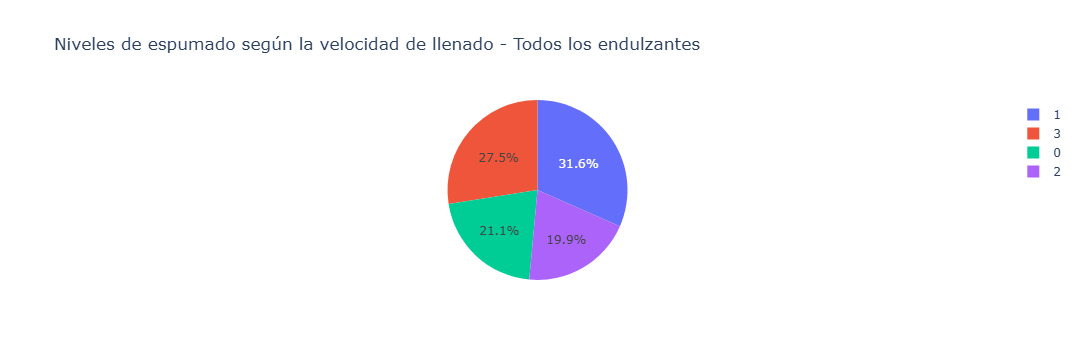

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\todos_los_endulzantes.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\todos_los_endulzantes.png


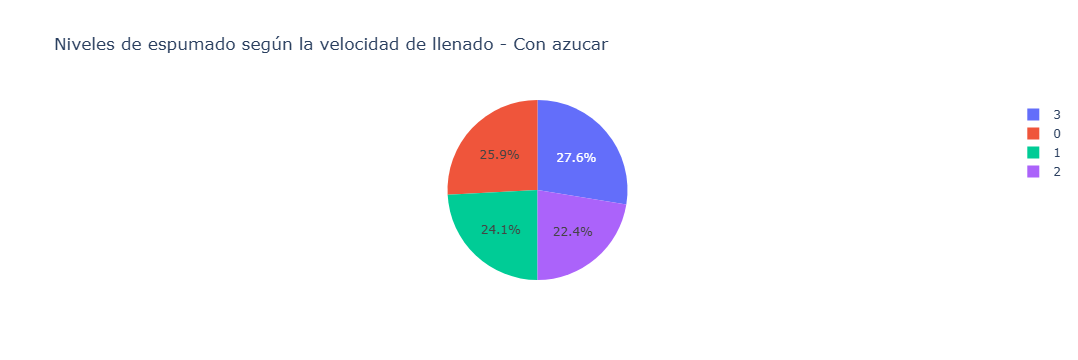

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\con_azucar.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\con_azucar.png


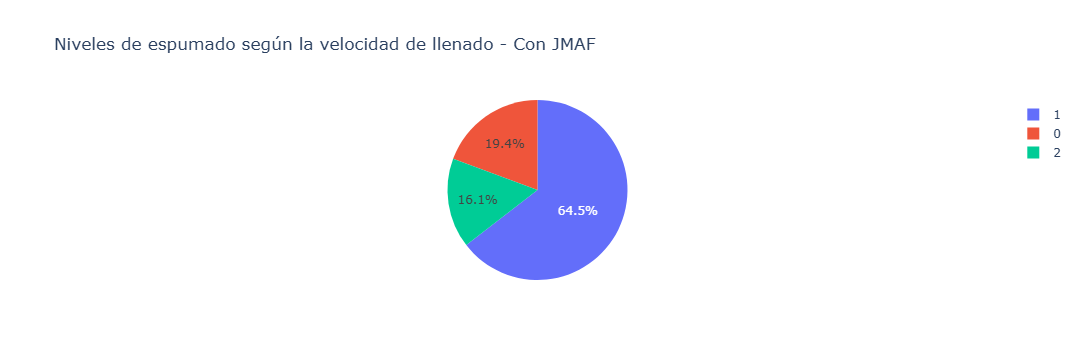

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\con_JMAF.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\con_JMAF.png


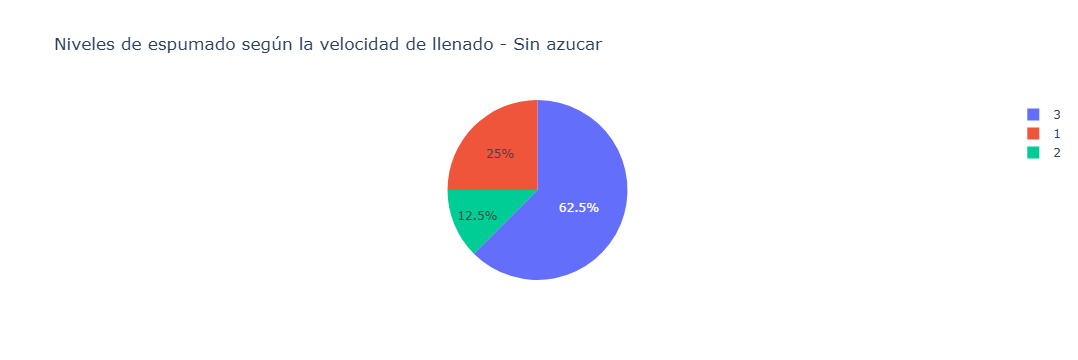

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\sin_azucar.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\sin_azucar.png


In [13]:
data = [df_copia, df_ConAzucar, df_jmaf, df_SinAzucar]

titles = [
    "Todos los endulzantes",
    "Con azucar",
    "Con JMAF",
    "Sin azucar"
]

file_names = [
    "todos_los_endulzantes",
    "con_azucar",
    "con_JMAF",
    "sin_azucar"
]

for df_actual, titulo, nombre_archivo in zip(data, titles, file_names):

    # Contar las ocurrencias de cada nivel de espumado
    counts = (
        df_actual["Nivel de espumado"]
        .value_counts()
        .reset_index()
    )

    counts.columns = ["Nivel de espumado", "count"]

    # Crear gráfico de torta
    fig = px.pie(
        counts,
        names="Nivel de espumado",
        values="count",
        title=f"Niveles de espumado según la velocidad de llenado - {titulo}"
    )

    # Mostrar gráfico
    fig.show()

    # Guardar HTML + PNG
    save_plotly_figure(
        fig,
        nombre_archivo
    )

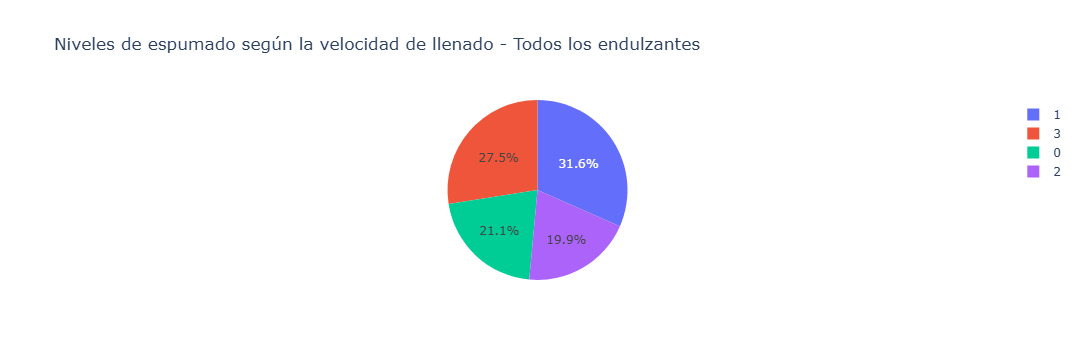

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\todos_los_endulzantes.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\todos_los_endulzantes.png


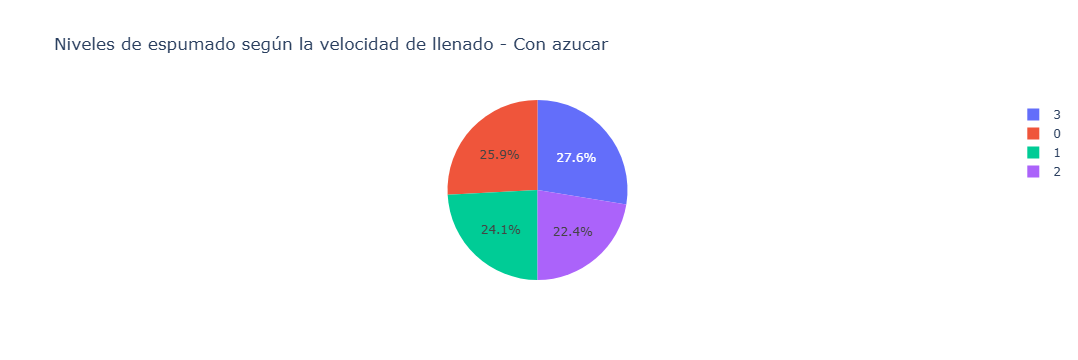

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\con_azucar.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\con_azucar.png


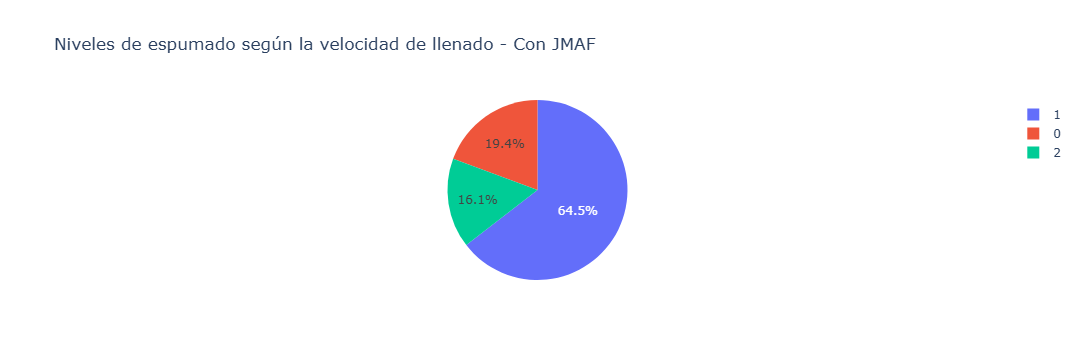

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\con_JMAF.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\con_JMAF.png


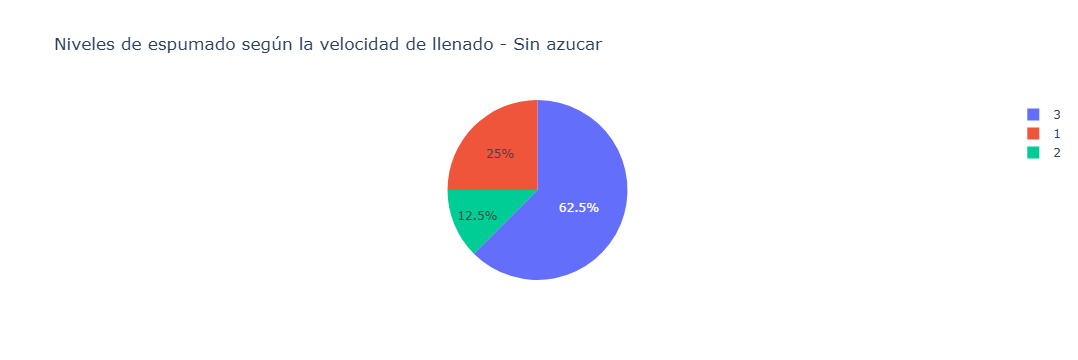

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\sin_azucar.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\sin_azucar.png


In [14]:
data = [df_copia, df_ConAzucar, df_jmaf, df_SinAzucar]

titles = [
    "Todos los endulzantes",
    "Con azucar",
    "Con JMAF",
    "Sin azucar"
]

file_names = [
    "todos_los_endulzantes",
    "con_azucar",
    "con_JMAF",
    "sin_azucar"
]

for df_actual, titulo, nombre_archivo in zip(data, titles, file_names):

    # Contar las ocurrencias de cada nivel de espumado
    counts = (
        df_actual["Nivel de espumado"]
        .value_counts()
        .reset_index()
    )

    counts.columns = ["Nivel de espumado", "count"]

    # Crear gráfico de torta
    fig = px.pie(
        counts,
        names="Nivel de espumado",
        values="count",
        title=f"Niveles de espumado según la velocidad de llenado - {titulo}"
    )

    # Mostrar gráfico
    fig.show()

    # Guardar HTML + PNG
    save_plotly_figure(
        fig,
        nombre_archivo
    )

### Interpretación

Al observar los gráficos anteriores, podemos apreciar la distribución porcentual de las distintas muestras según su clasificación en niveles de espumado. Podemos resaltar que las muestras sin azúcar tienen mayores problemas de espumado, ya que el 62.5% de las muestras corresponden a una clasificación de nivel 3, lo que indica que la velocidad de embotellado es muy baja cuando se producen los episodios de espumado.

Las bebidas sin azúcar tienden a presentar más problemas de espumado debido a la interacción entre la tensión superficial y la composición de los endulzantes artificiales.

El azúcar (sacarosa) tiene la capacidad de reducir la tensión superficial del líquido. La tensión superficial es la fuerza que mantiene unidas las moléculas en la superficie de un líquido, y su reducción puede ayudar a controlar la formación de burbujas y espuma. En las bebidas sin azúcar, la tensión superficial puede ser mayor debido a la ausencia de sacarosa, lo que facilita la formación de burbujas y, por consiguiente, un mayor espumado.

Por otro lado, los endulzantes artificiales como el aspartamo, la sucralosa y otros, presentan propiedades químicas distintas a las del azúcar. Estos compuestos no solo no reducen la tensión superficial de la misma manera que la sacarosa, sino que también pueden interactuar de manera diferente con el CO2 disuelto en la bebida y la matriz líquida en general. Esta interacción puede afectar tanto la formación como la estabilidad de la espuma, incrementando los problemas de espumado en las bebidas sin azúcar.

En conjunto, la mayor tensión superficial debida a la ausencia de azúcar y las distintas propiedades químicas de los endulzantes artificiales contribuyen a los problemas de espumado en las bebidas sin azúcar.

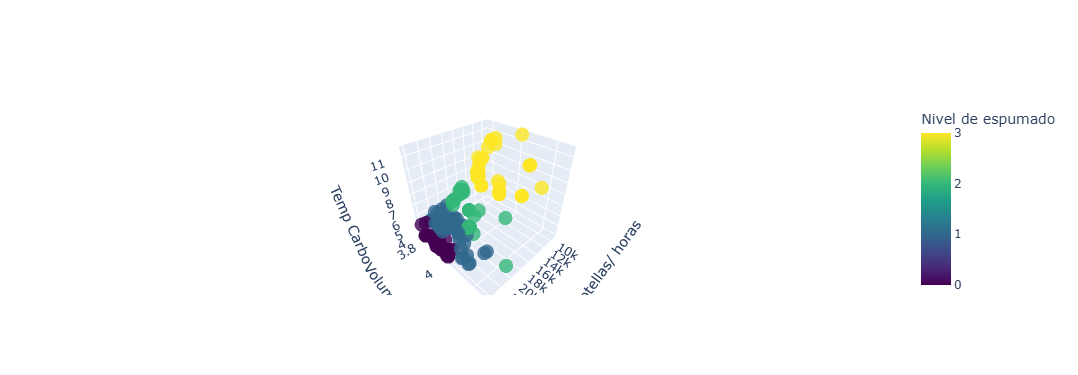

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\3d_temp_volCO2_Velocidad.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\3d_temp_volCO2_Velocidad.png


In [15]:
# Graficamos en 3D para observar como se mueven los valores de temperatura y
# volumen de CO2 con respecto a la velocidad de llenedo.

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=df['Vel_llenado _botellas/ horas'],
    y=df['Volumen CO2'],
    z=df['Temp Carbo'],
    mode='markers',
    marker=dict(
        size=8,
        color=df['Nivel de espumado'],
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Nivel de espumado')
    )
))

fig.update_layout(scene=dict(
                    xaxis_title='Vel_llenado _botellas/ horas',
                    yaxis_title='Volumen CO2',
                    zaxis_title='Temp Carbo'),
                    )
fig.show()
plt.close()

save_plotly_figure(
    fig,
    "3d_temp_volCO2_Velocidad"
)

### Interpretación

En el gráfico anterior, podemos ver que existe una relación entre la velocidad de embotellado, la temperatura de la bebida y el volumen de CO2: mientras más baja es la temperatura y los valores de CO2, más alta es la velocidad de llenado.

Esto se debe a dos posibles factores:

Solubilidad del CO2: El dióxido de carbono (CO2) es más soluble en líquidos a temperaturas más bajas. A temperaturas más bajas, el CO2 permanece disuelto en la bebida, lo que reduce la formación de burbujas y, por lo tanto, minimiza el espumado. Esto permite una mayor velocidad de llenado sin el riesgo de derrames.

Presión interna: A temperaturas más bajas, la presión interna dentro de la botella es menor, lo que facilita un llenado más rápido. A temperaturas más altas, la presión interna aumenta, lo que puede provocar un espumado excesivo y, por lo tanto, requiere una velocidad de llenado más lenta para evitar problemas.

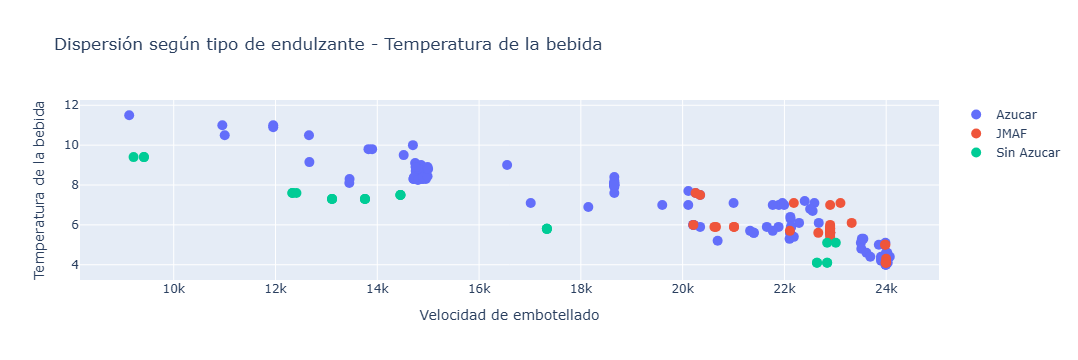

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\dispersion_temperatura_endulzante.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\dispersion_temperatura_endulzante.png


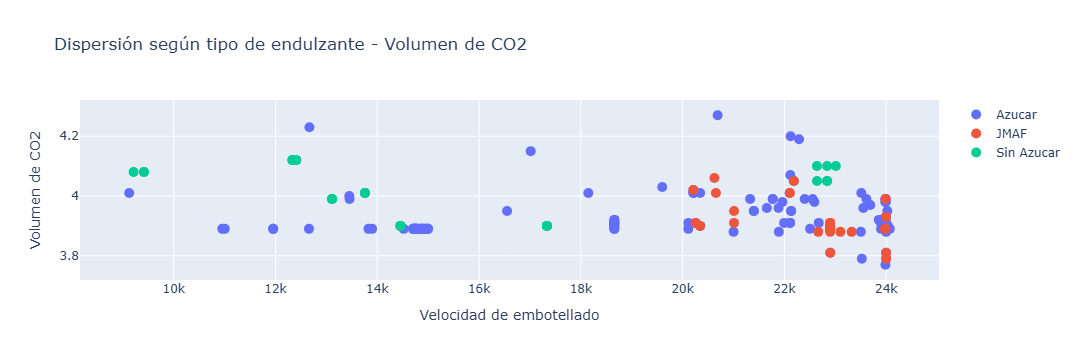

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\dispersion_volumen_CO2_endulzante.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\dispersion_volumen_CO2_endulzante.png


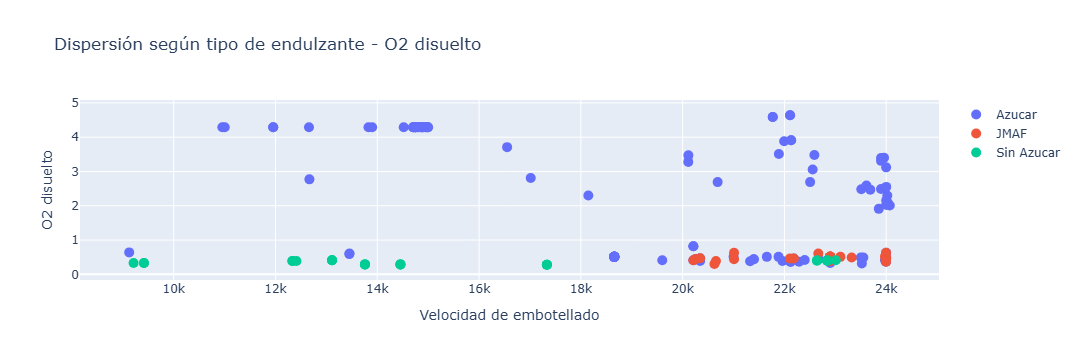

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\dispersion_O2_endulzante.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\dispersion_O2_endulzante.png


In [16]:
# ==========================================================
# Dispersión según tipo de endulzante
# ==========================================================

y_variables = [
    "Temp Carbo",
    "Volumen CO2",
    "O2 ing carbo"
]

y_titles = [
    "Temperatura de la bebida",
    "Volumen de CO2",
    "O2 disuelto"
]

file_names = [
    "dispersion_temperatura_endulzante",
    "dispersion_volumen_CO2_endulzante",
    "dispersion_O2_endulzante"
]


for y_var, y_title, file_name in zip(
    y_variables,
    y_titles,
    file_names
):

    fig = go.Figure()

    # Azúcar
    fig.add_trace(
        go.Scatter(
            x=df_ConAzucar["Vel_llenado _botellas/ horas"],
            y=df_ConAzucar[y_var],
            mode="markers",
            name="Azucar",
            marker=dict(size=10)
        )
    )

    # JMAF
    fig.add_trace(
        go.Scatter(
            x=df_jmaf["Vel_llenado _botellas/ horas"],
            y=df_jmaf[y_var],
            mode="markers",
            name="JMAF",
            marker=dict(size=10)
        )
    )

    # Sin azúcar
    fig.add_trace(
        go.Scatter(
            x=df_SinAzucar["Vel_llenado _botellas/ horas"],
            y=df_SinAzucar[y_var],
            mode="markers",
            name="Sin Azucar",
            marker=dict(size=10)
        )
    )

    # Configuración del gráfico
    fig.update_layout(
        title=f"Dispersión según tipo de endulzante - {y_title}",
        xaxis_title="Velocidad de embotellado",
        yaxis_title=y_title,
    )

    # Mostrar
    fig.show()

    # Guardar HTML + PNG
    save_plotly_figure(
        fig,
        file_name
    )

# 9. Preparación de datos

In [17]:
# Separamos las variables target del resto de las caracaterísticas.
# Eliminamos de "df" características consideradas irrelevantes.
X = df.drop(columns = ['Nivel de espumado', 'Vel_llenado _botellas/ horas','Azucar', 'JMAF', 'O2 desaireador', 'O2 cwc'])
y = df['Nivel de espumado']
print(X.columns)
y.unique()

Index(['O2 ing carbo', 'Set factor CO2', 'Volumen CO2', 'Temp botella',
       'Temp Carbo', 'Sin Azucar'],
      dtype='str')


array([3, 1, 2, 0])

# 10. Entrenamiento de modelos

### Asignar valores monetarios a los diferentes resultados para valorizar cada cuadrante de mi matriz de confusión

In [18]:

beneficio_tp = 1.0 #por botellas correctamente clasificadas como con espumado aceptable. (precio de venta)
costo_fp = 0.8 #Pérdida por cada botella incorrectamente clasificada como aceptable, que puede llevar a reclamos o mala reputación. (costo de producción + posible impacto negativo)
beneficio_tn = 0.6 #por botellas correctamente clasificadas como con espumado no aceptable. (ahorro del costo de producción)
costo_fn = 0.6 #Pérdida por desechar una botella que en realidad es aceptable. (costo de producción de una botella desperdiciada)

def calcular_costo_beneficio(y_true, y_pred, costo_fp, costo_fn, beneficio_tp, beneficio_tn, filename=None):
    # Generamos la matriz de confusión a partir de las etiquetas verdaderas y predichas
    cm = confusion_matrix(y_true, y_pred)

    # Creamos un DataFrame a partir de la matriz de confusión para usar con Plotly Express
    cm_df = pd.DataFrame(cm, index=[f"Actual {i}" for i in range(len(cm))], columns=[f"Predicted {i}" for i in range(len(cm))])

    # Convertimos el DataFrame a un formato largo para Plotly Express
    cm_long = cm_df.reset_index().melt(id_vars='index', value_name='count').rename(columns={'index': 'Actual'})

    # Creamos la matriz de confusión interactiva con Plotly Express
    fig = px.imshow(cm,
                    labels=dict(x="Predicted", y="Actual", color="Count"),
                    x=[f"Predicted {i}" for i in range(len(cm))],
                    y=[f"Actual {i}" for i in range(len(cm))],
                    text_auto=True,
                    color_continuous_scale='Viridis')

    # Mostramos la matriz de confusión interactiva
    fig.update_layout(
        title="Confusion Matrix",
        xaxis=dict(title="Predicted Label"),
        yaxis=dict(title="True Label")
    )
    fig.show()

    # 💾 Si especificas un nombre de archivo, guarda el PNG y HTML automáticamente
    if filename:
        save_plotly_figure(fig, filename)

    # Inicializamos el costo y beneficio total
    total_costo = 0
    total_beneficio = 0

    # Recorremos cada clase en la matriz de confusión
    for i in range(len(cm)):
        tn = sum(cm[j][k] for j in range(len(cm)) for k in range(len(cm)) if j != i and k != i)
        tp = cm[i][i]
        fp = sum(cm[j][i] for j in range(len(cm)) if j != i)
        fn = sum(cm[i][j] for j in range(len(cm)) if j != i)

        # Sumamos el costo total
        total_costo += (fp * costo_fp) + (fn * costo_fn)
        # Sumamos el beneficio total
        total_beneficio += (tp * beneficio_tp) + (tn * beneficio_tn)

    # Retornamos la diferencia entre el beneficio total y el costo total
    return total_beneficio - total_costo


### Árbol de decisiones

In [19]:
# Separamos el dataset en conjunto de entrenamiento y testeo.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 16, stratify=y)

#Guardamos en una variable el tipo de parametro criterion.
criterio='entropy'
#criterio='gini'

# Inicializamos un clasificador de árbol de decisión con el criterio especificado.
arbol=DecisionTreeClassifier(criterion=criterio)

# Entrenamos el clasificador en el conjunto de entrenamiento.
arbol.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

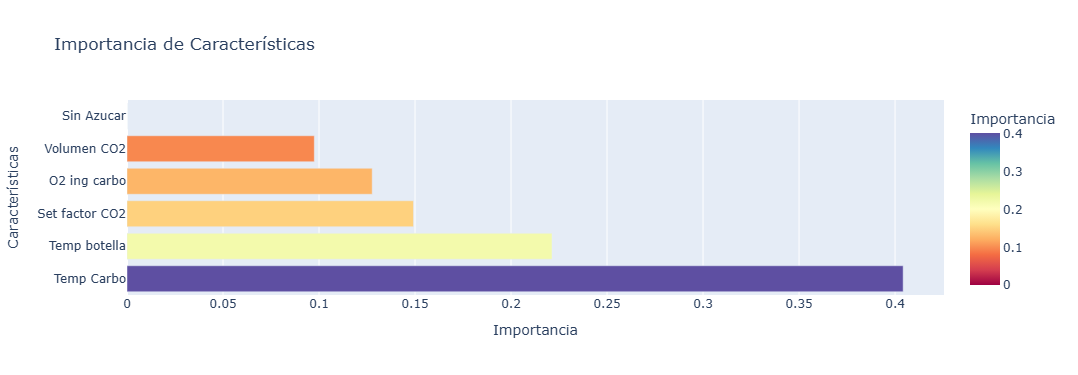

[0.12769745 0.14919179 0.09754679 0.22134829 0.40421569 0.        ]
✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\importancia_de_caractersticas_arbol.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\importancia_de_caractersticas_arbol.png


In [20]:
# Vemos que variables pesaron mas en las decisiones del árbol.
fi=arbol.feature_importances_
fi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': fi
})
fig = px.bar(
    fi_df.sort_values('Importance', ascending=False),
    x='Importance',
    
    y='Feature',
    orientation='h',
    title='Importancia de Características',
    labels={'Importance': 'Importancia', 'Feature': 'Características'},
    color='Importance',
    color_continuous_scale='Spectral'
)
fig.show()
print(fi)

save_plotly_figure(
    fig,
    "importancia_de_caractersticas_arbol"
)

Interpretación

El árbol de decisión toma las decisiones en varios niveles basándose en las características "Temp botella", "Volumen CO2", "Temp Carbo", y "O2 ing carbo". Cada división en el árbol intenta separar las muestras de manera que las submuestras sean lo más puras posible en términos de la clase objetivo. Las hojas finales representan la clase predicha para las muestras que llegan a ese nodo.

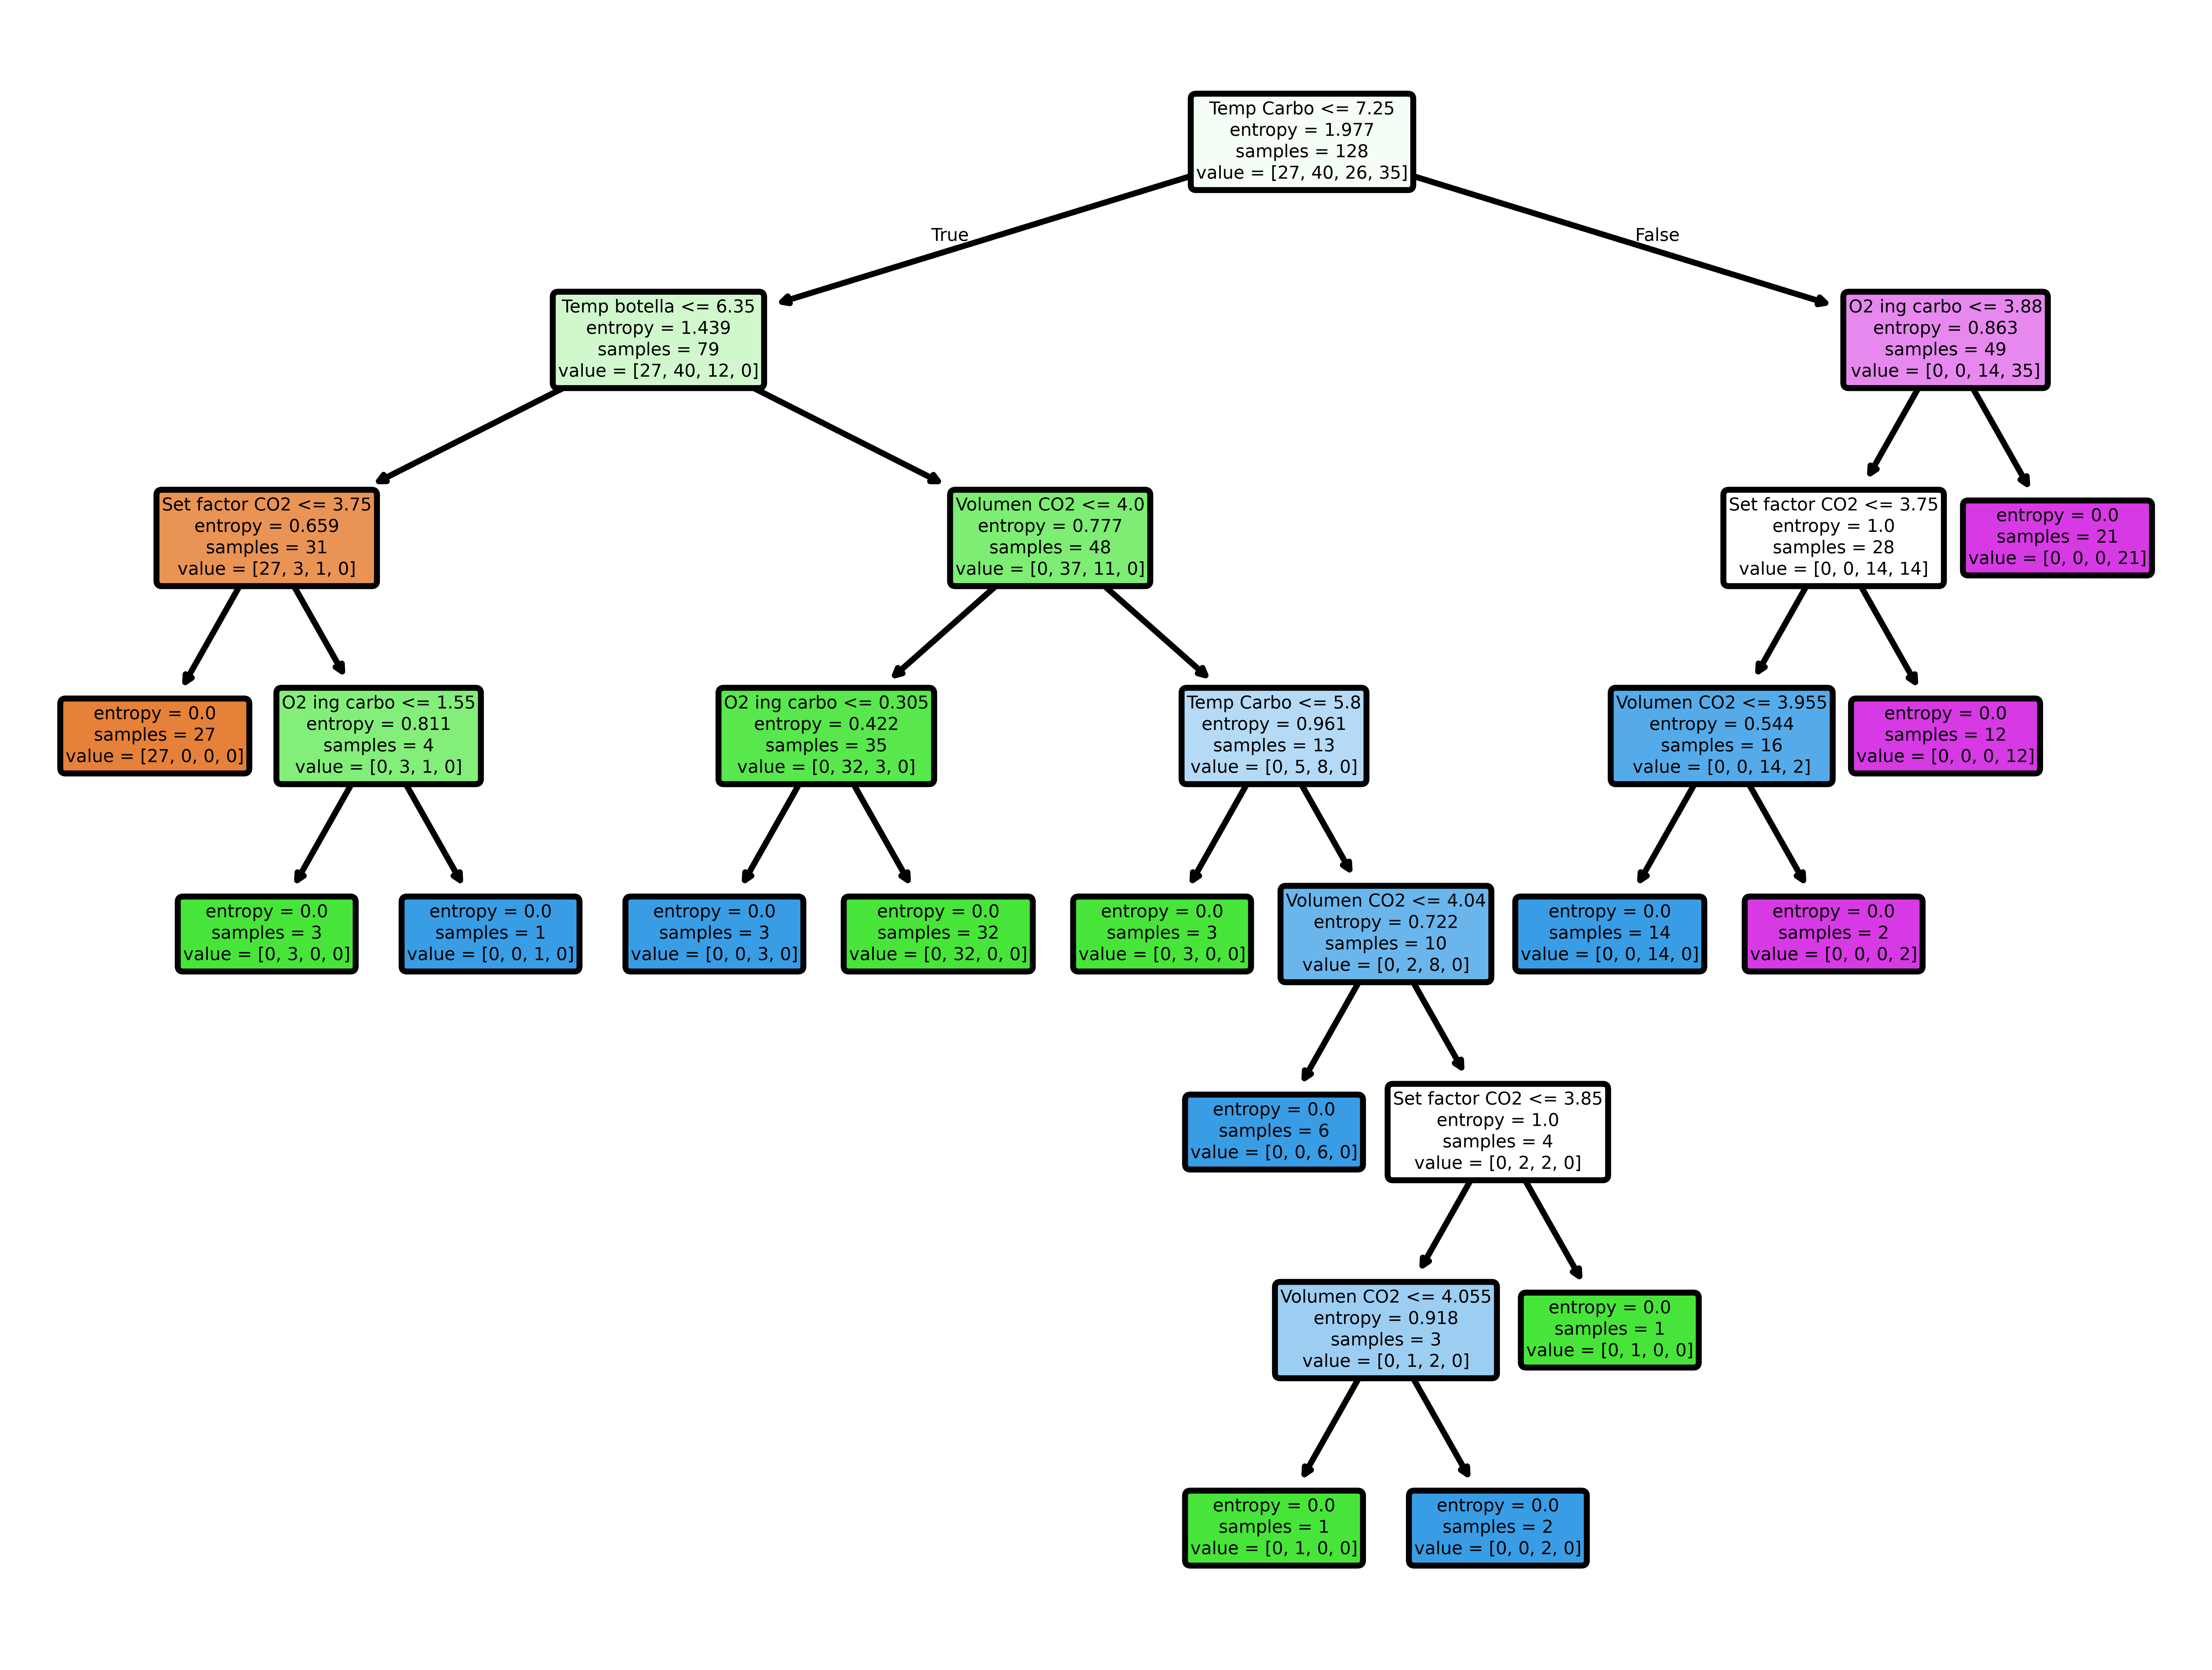

✅ PNG guardado en: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\grafo_arbol.png


In [21]:
# Graficamos el árbol.
list_features=list(X.columns)
plt.figure(dpi=1500)
plot_tree(arbol, filled=True, rounded=True, feature_names=list_features)

# Guardar la figura usando Matplotlib antes de plt.show() / plt.close()
# Carpeta donde se almacenarán las figuras
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURES_DIR / "grafo_arbol.png"
plt.savefig(png_path, bbox_inches='tight')

plt.show()
plt.close()

print(f"✅ PNG guardado en: {png_path}")

Score train:  1.0
Score test:   0.9534883720930233
Decision Tree Accuracy: 0.9534883720930233
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.93      0.93      0.93        14
           2       0.88      0.88      0.88         8
           3       1.00      1.00      1.00        12

    accuracy                           0.95        43
   macro avg       0.95      0.95      0.95        43
weighted avg       0.95      0.95      0.95        43



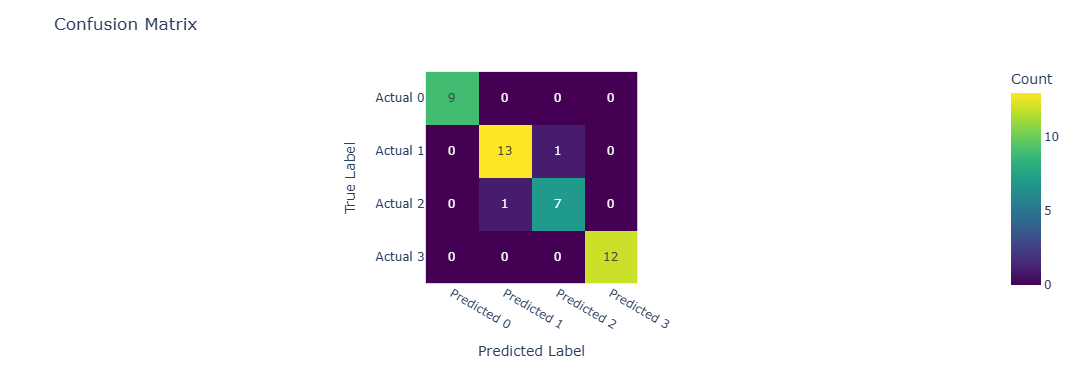

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\matriz_confusion_arbol.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\matriz_confusion_arbol.png
Beneficio neto para el árbol: 114.39999999999999


In [22]:
# Hacemos predicciones y vemos si el árbol está sobreajustado.
y_pred = arbol.predict(X_test)

# Calculamos y mostramos la precisión del modelo en los datos de entrenamiento.
print('Score train: ', arbol.score(X_train, y_train))

# Calculamos y mostramos la precisión del modelo en los datos de prueba.
print('Score test:  ', arbol.score(X_test, y_test))

# Calculamos la precisión del modelo de árbol de decisión utilizando las
# etiquetas verdaderas 'y_test' y las predicciones 'y_pred'. 'accuracy_score'
# retorna la proporción de predicciones correctas.
tree_accuracy = accuracy_score(y_test, y_pred)

# Imprimimos la precisión del modelo de árbol de decisión.
print("Decision Tree Accuracy:", tree_accuracy)
# Imprimimos el informe de clasificación que incluye métricas como precisión, recall y F1-score
# para cada clase. 'classification_report' genera un informe de estas métricas.
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred))

# Calculamos el beneficio neto del modelo de árbol de decisión utilizando la función 'calcular_costo_beneficio'.
# Esta función toma como parámetros las etiquetas verdaderas 'y_test', las predicciones 'y_pred',
# el costo de falsos positivos 'costo_fp', el costo de falsos negativos 'costo_fn',
# y el beneficio de verdaderos positivos 'beneficio_tp' y verdaderos negativos 'beneficio_tn'.
beneficio_neto = calcular_costo_beneficio(y_test,
                                          y_pred,
                                          costo_fp,
                                          costo_fn,
                                          beneficio_tp,
                                          beneficio_tn,
                                          filename="matriz_confusion_arbol"
                                    )
print(f"Beneficio neto para el árbol: {beneficio_neto}")

In [23]:
# Vemos la máxima profundidad y la cantidad de ojas que desarrolló nuestro árbol.

# Imprime la máxima profundidad del árbol de decisión
print(f'Máxima profundidad: {arbol.get_depth()}')
# Imprime la cantidad de hojas del árbol de decisión
print(f'Cantidad de hojas: {arbol.get_n_leaves()}')

# Crea una lista de profundidades del 1 al 7
depth=[i+1 for i in range(7)]
# Inicializa listas vacías para almacenar los puntajes de entrenamiento y prueba
scor_train=[]
scor_test=[]
# Itera sobre cada profundidad en la lista de profundidades
for dep in depth:
  # Crea un modelo de árbol de decisión con la profundidad máxima especificada
    tree=DecisionTreeClassifier(criterion=criterio, max_depth=dep, random_state = 16)
    tree.fit(X_train, y_train)
    pred=tree.predict(X_test)

    print(f'Profundidad: {dep}')
    print(f'Precisión train: {tree.score(X_train, y_train)}')
    print(f'Precisión test: {tree.score(X_test, y_test)}')

    scor_train.append(tree.score(X_train, y_train))
    scor_test.append(tree.score(X_test, y_test))


Máxima profundidad: 7
Cantidad de hojas: 14
Profundidad: 1
Precisión train: 0.5859375
Precisión test: 0.6046511627906976
Profundidad: 2
Precisión train: 0.7734375
Precisión test: 0.7441860465116279
Profundidad: 3
Precisión train: 0.9140625
Precisión test: 0.9069767441860465
Profundidad: 4
Precisión train: 0.984375
Precisión test: 0.9302325581395349
Profundidad: 5
Precisión train: 0.984375
Precisión test: 0.9767441860465116
Profundidad: 6
Precisión train: 0.9921875
Precisión test: 0.9302325581395349
Profundidad: 7
Precisión train: 1.0
Precisión test: 0.9534883720930233


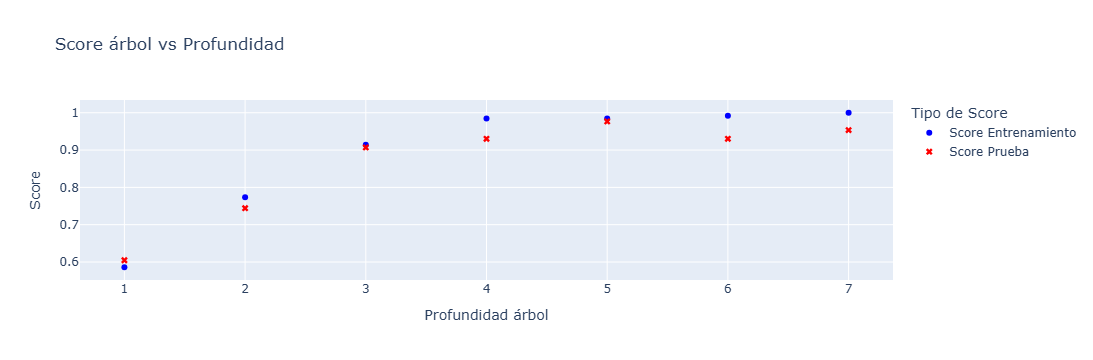

In [24]:
# Grafico para identificar la profundidad conveniente del árbol.
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=depth, y=scor_train,
    mode='markers',
    marker=dict(color='blue', symbol='circle'),
    name='Score Entrenamiento'
))


fig.add_trace(go.Scatter(
    x=depth, y=scor_test,
    mode='markers',
    marker=dict(color='red', symbol='x'),
    name='Score Prueba'
))


fig.update_layout(
    title='Score árbol vs Profundidad',
    xaxis_title='Profundidad árbol',
    yaxis_title='Score',
    legend_title='Tipo de Score'
)

fig.show()
plt.close()

In [25]:
# Otro criterio es regular la cantidad de muestras por cada hoja
samplex=[i+1 for i in range(7)]
scor_train1=[]
scor_test1=[]
for sam in samplex:
    arbol=DecisionTreeClassifier(criterion=criterio, min_samples_leaf=sam, random_state = 16)
    arbol.fit(X_train, y_train)
    pred=arbol.predict(X_test)

    print(f'Profundidad: {sam}')
    print(f'Precisión train: {arbol.score(X_train, y_train)}')
    print(f'Precisión test: {arbol.score(X_test, y_test)}')

    scor_train1.append(arbol.score(X_train, y_train))
    scor_test1.append(arbol.score(X_test, y_test))

Profundidad: 1
Precisión train: 1.0
Precisión test: 0.9534883720930233
Profundidad: 2
Precisión train: 0.9765625
Precisión test: 0.9767441860465116
Profundidad: 3
Precisión train: 0.96875
Precisión test: 0.9302325581395349
Profundidad: 4
Precisión train: 0.9375
Precisión test: 0.9534883720930233
Profundidad: 5
Precisión train: 0.90625
Precisión test: 0.8837209302325582
Profundidad: 6
Precisión train: 0.890625
Precisión test: 0.813953488372093
Profundidad: 7
Precisión train: 0.890625
Precisión test: 0.8372093023255814


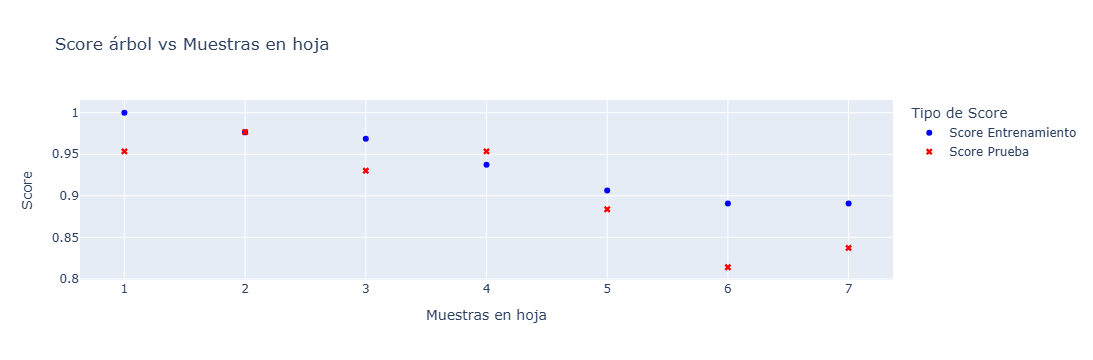

In [26]:
# Grafico para identificar la cantidad de muestras por hoja convenientes del árbol.
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=samplex, y=scor_train1,
    mode='markers',
    marker=dict(color='blue', symbol='circle'),
    name='Score Entrenamiento'
))


fig.add_trace(go.Scatter(
    x=samplex, y=scor_test1,
    mode='markers',
    marker=dict(color='red', symbol='x'),
    name='Score Prueba'
))


fig.update_layout(
    title='Score árbol vs Muestras en hoja',
    xaxis_title='Muestras en hoja',
    yaxis_title='Score',
    legend_title='Tipo de Score'
)

fig.show()

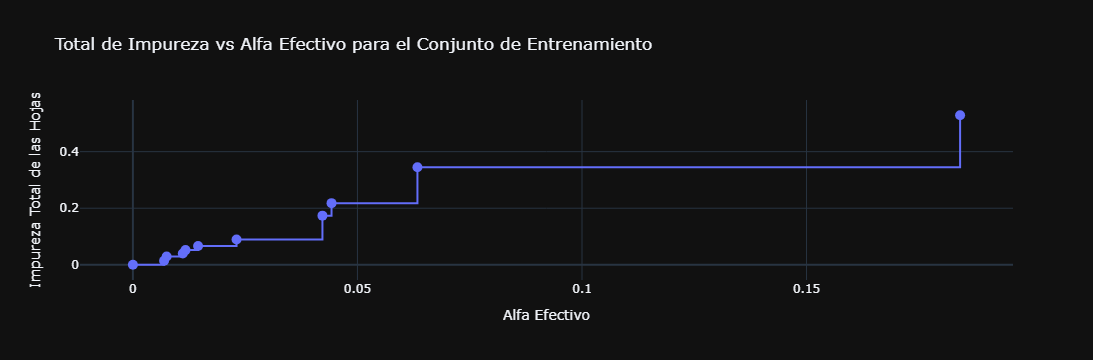

In [27]:
# Otro método para evitar overfiting: poda posterior (cost_complexity_pruning_path)
# Crear un clasificador de árbol de decisión con semilla aleatoria
clas = DecisionTreeClassifier(random_state=16)
# Calcular la ruta de poda por complejidad de costo
path = clas.cost_complexity_pruning_path(X_train, y_train)
# Obtener los alfas de poda y las impurezas correspondientes
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Crear una figura de Plotly
fig = go.Figure()

# Agregar una línea con marcadores para mostrar Impurity vs Alpha
fig.add_trace(go.Scatter(
    x=ccp_alphas[:-1], y=impurities[:-1],
    mode='lines+markers',
    marker=dict(symbol='circle', size=10),
    line=dict(shape='hv'),
    name='Impurity vs Alpha'
))

# Actualizar el diseño del gráfico
fig.update_layout(
    title='Total de Impureza vs Alfa Efectivo para el Conjunto de Entrenamiento',
    xaxis_title='Alfa Efectivo',
    yaxis_title='Impureza Total de las Hojas',
    template='plotly_dark'
)
fig.show()

In [28]:
# Generamos una serie de árboles de decisión con diferentes valores de
# ccp_alpha
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=16, ccp_alpha = ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Número de nodos en el último árbol es: {} con ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Número de nodos en el último árbol es: 1 con ccp_alpha: 0.212944706784019


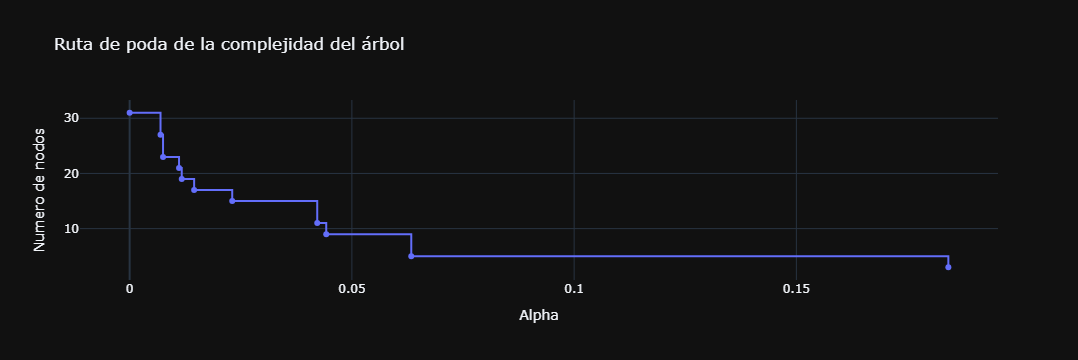

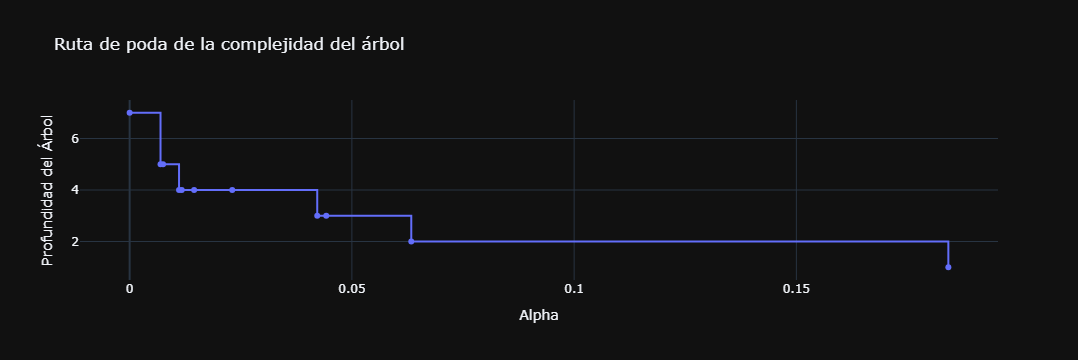

In [29]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Obtener el número de nodos y profundidad para cada árbol en clfs
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

# Crear una figura de Plotly
fig = go.Figure()
fig_1 = go.Figure()

fig.add_trace(go.Scatter(
    x=ccp_alphas,
    y=node_counts,
    mode='lines+markers',
    name='Number of nodes',
    line=dict(shape='hv')
))

# Crear el gráfico de profundidad vs alpha
fig_1.add_trace(go.Scatter(
    x=ccp_alphas,
    y=depth,
    mode='lines+markers',
    name='Depth of tree',
    line=dict(shape='hv'),
    yaxis="y"
))

# Actualizar el layout para incluir dos ejes y títulos
fig.update_layout(
    title="Ruta de poda de la complejidad del árbol",
    xaxis=dict(title='Alpha'),
    yaxis=dict(title='Numero de nodos'),
    legend=dict(x=0.01, y=0.99),
    template='plotly_dark'
)

fig_1.update_layout(
    title="Ruta de poda de la complejidad del árbol",
    xaxis=dict(title='Alpha'),
    yaxis=dict(title='Profundidad del Árbol'),
    legend=dict(x=0.01, y=0.99),
    template='plotly_dark'
)

fig.show()
fig_1.show()


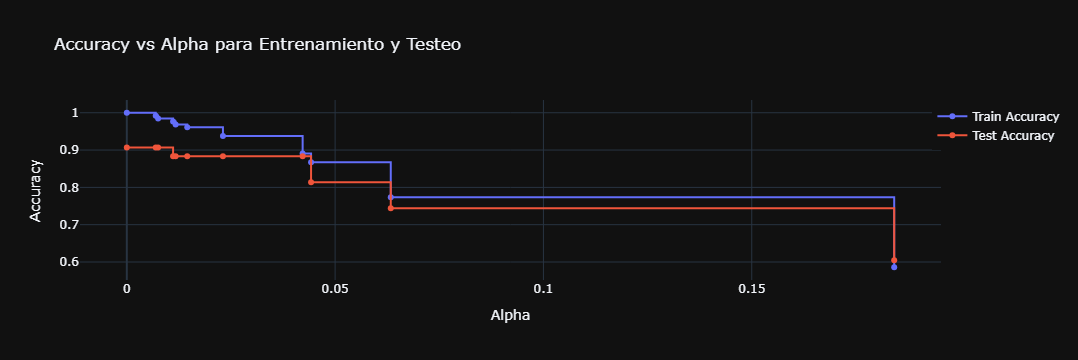

In [30]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

# Crear una figura de Plotly
fig = go.Figure()

# Añadir la precisión del conjunto de entrenamiento
fig.add_trace(go.Scatter(
    x=ccp_alphas,
    y=train_scores,
    mode='lines+markers',
    name='Train Accuracy',
    line=dict(shape='hv')
))

# Añadir la precisión del conjunto de prueba
fig.add_trace(go.Scatter(
    x=ccp_alphas,
    y=test_scores,
    mode='lines+markers',
    name='Test Accuracy',
    line=dict(shape='hv')
))

# Actualizar el layout para incluir títulos y etiquetas
fig.update_layout(
    title="Accuracy vs Alpha para Entrenamiento y Testeo",
    xaxis=dict(title='Alpha'),
    yaxis=dict(title='Accuracy'),
    legend=dict(x=0.99, y=0.99),
    template='plotly_dark'
)

fig.show()



In [31]:
# Buscamos identificar el mejor valor de ccp_alpha para el árbol de decisión
alfas=ccp_alphas
scor=np.array(test_scores)

alfa_score=pd.DataFrame({'alpha':alfas, 'score':scor})
indice=alfa_score['score'].idxmax()
alfa_max=alfa_score['alpha'].iloc[indice]
print('Mejor alfa', alfa_max)
alfa_score.head(15)

Mejor alfa 0.0


,alpha,score
0,0.000000,0.906977
1,0.006944,0.906977
2,0.007512,0.906977
3,0.011111,0.883721
4,0.011719,0.883721
5,0.014509,0.883721
6,0.023077,0.883721
7,0.042205,0.883721
8,0.044229,0.813953
9,0.063359,0.744186


Score train:  0.9765625
Score test:   0.9767441860465116
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8
           3       1.00      1.00      1.00        12

    accuracy                           0.98        43
   macro avg       0.98      0.97      0.97        43
weighted avg       0.98      0.98      0.98        43



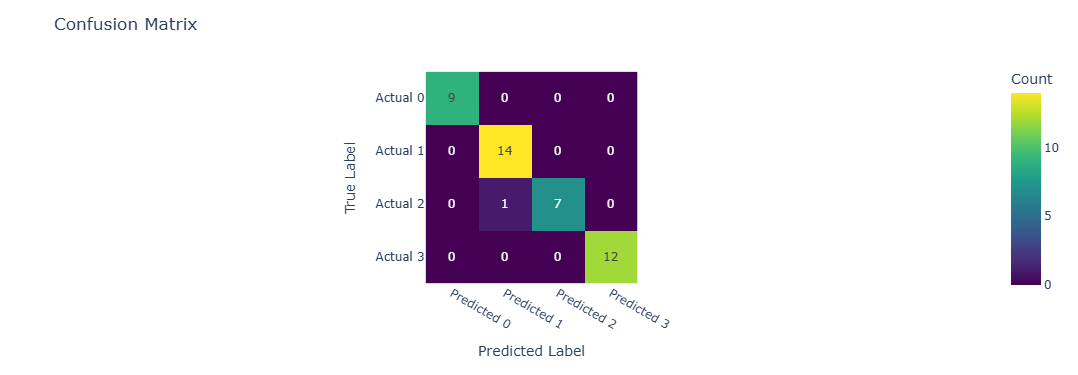

Beneficio neto para el árbol: 117.39999999999999


In [32]:
# Utilizamos un árbol de decisión con poda por complejidad y los
# hiperparametros de máxima profundidad (max_depth) y el Número mínimo de
# muestras requeridas para ser una hoja (min_sample_leaf)
arbol_alfa=DecisionTreeClassifier(criterion=criterio, ccp_alpha = 0.006944, max_depth = 5, min_samples_leaf = 2)   #,ccp_alpha=alfa_best , class_weight='balanced')
arbol_alfa.fit(X_train, y_train)
y_pred_alfa = arbol_alfa.predict(X_test)

y_pred = arbol_alfa.predict(X_test)

# Calculamos y mostramos la presición del modelo con los datos de entrenamiento
print('Score train: ', arbol_alfa.score(X_train, y_train))
# Calculamos y mostramos la presición del modelo con los datos de prueba
print('Score test:  ', arbol_alfa.score(X_test, y_test))
# Imprimimos el informe de clasificación que incluye métricas como precisión, recall y F1-score
# para cada clase. 'classification_report' genera un informe de estas métricas.
print(classification_report(y_test, y_pred))
# Calculamos el beneficio neto del modelo de árbol de decisión utilizando la función 'calcular_costo_beneficio'.
# Esta función toma como parámetros las etiquetas verdaderas 'y_test', las predicciones 'y_pred',
# el costo de falsos positivos 'costo_fp', el costo de falsos negativos 'costo_fn',
# y el beneficio de verdaderos positivos 'beneficio_tp' y verdaderos negativos
# 'beneficio_tn'
beneficio_neto = calcular_costo_beneficio(y_test, y_pred, costo_fp, costo_fn, beneficio_tp, beneficio_tn)
print(f"Beneficio neto para el árbol: {beneficio_neto}")

# 11. Evaluación de modelos

La línea de producción en cuestión tiene una capacidad de embotellado de 24,000 botellas por hora. Debido a la intensidad de los episodios de espumado, esta velocidad se ve disminuida. Hemos clasificado los niveles de espumado en cuatro categorías según la velocidad de embotellado que dicho espumado nos permita alcanzar.


Sin espumado "0": entre 23500 a 24000 b/h

Espumado bajo "1": un promedio de 22161.5 b/h

Espumado medio: "2": un promedio de 18619.5 b/h

Espumado alto: "3": un promedio de 12062 b/h


Teniendo en cuenta este contexto calcularemos el beneficio neto considerando los beneficios de los verdadero positivos y negativos como así también el costo de los falsos positivos y negativos.


beneficio_vp = $1.0 por botellas correctamente clasificadas como con espumado aceptable. (precio de venta)

costo_fp = $0.8 Pérdida por cada botella incorrectamente clasificada como aceptable, que puede llevar a reclamos o mala reputación. (costo de producción + posible impacto negativo)

beneficio_vn = $0.6 por botellas correctamente clasificadas como con espumado no aceptable. (ahorro del costo de producción)

costo_fn = $0.6 Pérdida por desechar una botella que en realidad es aceptable. (costo de producción de una botella desperdiciada)



In [33]:
# Escalamos las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Mejores parametros de Vecinos cercanos: KNeighborsClassifier(n_neighbors=7, weights='distance')
Mejores parametros de Árbol de decisión: DecisionTreeClassifier(max_depth=10)
Mejores parámetros de Máquina de soporte vectorial: SVC(C=10, kernel='linear')
Mejor modelo de Naive Bayes: GaussianNB(var_smoothing=1e-07)



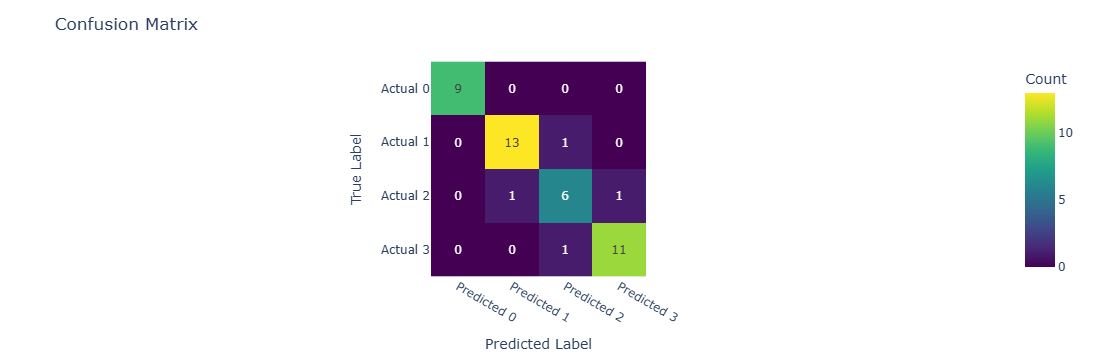

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\matriz_confusion KNN.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\matriz_confusion KNN.png
Beneficio neto para KNN: 108.4
Score train:  1.0
Score test:   0.9069767441860465

               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.93      0.93      0.93        14
           2       0.75      0.75      0.75         8
           3       0.92      0.92      0.92        12

    accuracy                           0.91        43
   macro avg       0.90      0.90      0.90        43
weighted avg       0.91      0.91      0.91        43



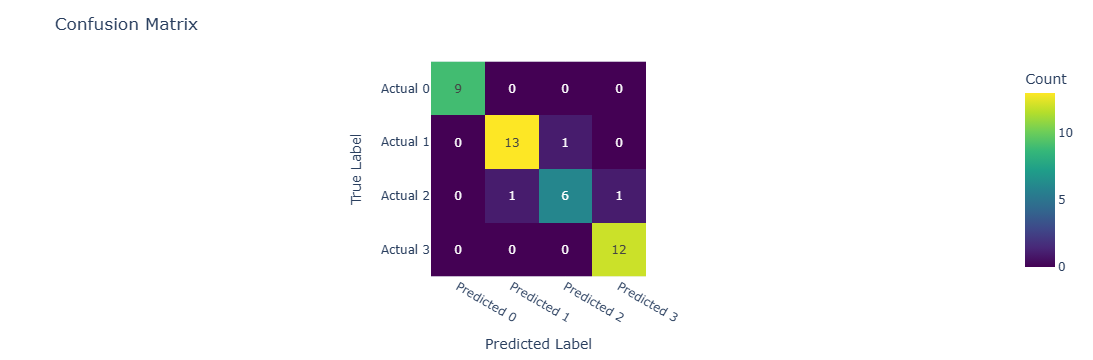

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\matriz_confusion Decision Tree.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\matriz_confusion Decision Tree.png
Beneficio neto para Decision Tree: 111.39999999999999
Score train:  1.0
Score test:   0.9302325581395349

               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.93      0.93      0.93        14
           2       0.86      0.75      0.80         8
           3       0.92      1.00      0.96        12

    accuracy                           0.93        43
   macro avg       0.93      0.92      0.92        43
weighted avg       0.93      0.93      0.93        43



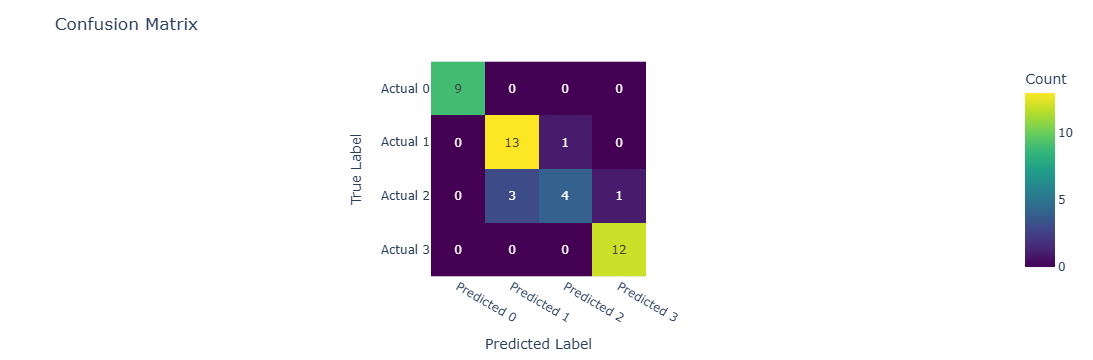

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\matriz_confusion SVM.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\matriz_confusion SVM.png
Beneficio neto para SVM: 105.4
Score train:  0.890625
Score test:   0.8837209302325582

               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.81      0.93      0.87        14
           2       0.80      0.50      0.62         8
           3       0.92      1.00      0.96        12

    accuracy                           0.88        43
   macro avg       0.88      0.86      0.86        43
weighted avg       0.88      0.88      0.87        43



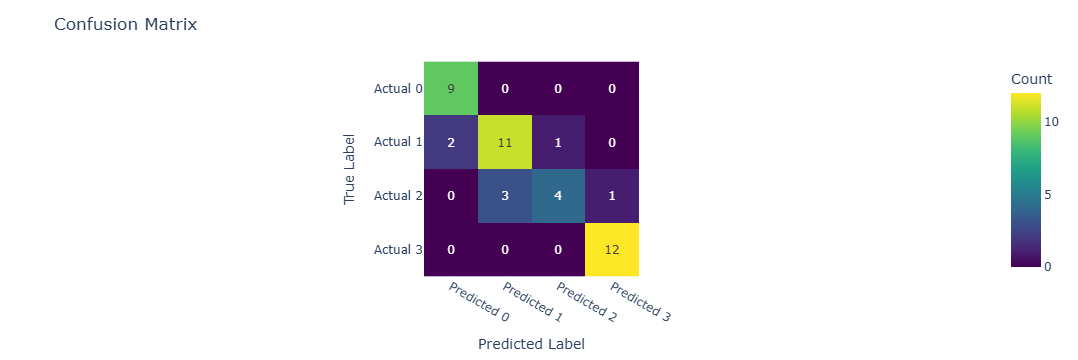

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\matriz_confusion Naive Bayes.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\matriz_confusion Naive Bayes.png
Beneficio neto para Naive Bayes: 99.39999999999999
Score train:  0.7578125
Score test:   0.8372093023255814

               precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       0.79      0.79      0.79        14
           2       0.80      0.50      0.62         8
           3       0.92      1.00      0.96        12

    accuracy                           0.84        43
   macro avg       0.83      0.82      0.82        43
weighted avg       0.83      0.84      0.83        43


El mejor modelo basado en el beneficio neto es: Decision Tree con un beneficio neto de 111.39999999999999


In [34]:
# Definimos los modelos clasificadores
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
svc = SVC()
nb = GaussianNB()

# Definimos los hiperparámetros a probar
param_grid_knn = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
param_grid_dt = {'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 10, 20]}
param_grid_svc = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
param_grid_nb = {'var_smoothing': [1e-9, 1e-8, 1e-7]}

# Usamos GridSearchCV para cada modelo
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy')
grid_svc = GridSearchCV(svc, param_grid_svc, cv=5, scoring='accuracy')
grid_nb = GridSearchCV(nb, param_grid_nb, cv=5, scoring='accuracy')

# Entrenamos y encontramos los mejores parámetros
grid_knn.fit(X_train, y_train)
grid_dt.fit(X_train, y_train)
grid_svc.fit(X_train, y_train)
grid_nb.fit(X_train, y_train)

# Obtener los mejores modelos
best_knn = grid_knn.best_estimator_
best_dt = grid_dt.best_estimator_
best_svc = grid_svc.best_estimator_
best_nb = grid_nb.best_estimator_

print(f"Mejores parametros de Vecinos cercanos: {best_knn}")
print(f"Mejores parametros de Árbol de decisión: {best_dt}")
print(f"Mejores parámetros de Máquina de soporte vectorial: {best_svc}")
print(f"Mejor modelo de Naive Bayes: {best_nb}""\n")

# Evaluamos los modelos en el conjunto de prueba
models = {'KNN': best_knn, 'Decision Tree': best_dt, 'SVM': best_svc, 'Naive Bayes': best_nb}

# Asignamos valores monetarios a los diferentes resultados
beneficio_vp = 1.0
costo_fp = 0.8
beneficio_vn = 0.6
costo_fn = 0.6

mejor_modelo = None
mejor_beneficio = float('-inf')

beneficios_netos = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    beneficio_neto = calcular_costo_beneficio(y_test,
                                          y_pred,
                                          costo_fp,
                                          costo_fn,
                                          beneficio_tp,
                                          beneficio_tn,
                                          filename= f"matriz_confusion {name}"
                                    )
    beneficios_netos.append((name, beneficio_neto))
    print(f"Beneficio neto para {name}: {beneficio_neto}")
    print('Score train: ', model.score(X_train, y_train))
    print('Score test:  ', model.score(X_test, y_test))
    print("\n",classification_report(y_test, y_pred))

    if beneficio_neto > mejor_beneficio:
        mejor_beneficio = beneficio_neto
        mejor_modelo = name

print(f"\nEl mejor modelo basado en el beneficio neto es: {mejor_modelo} con un beneficio neto de {mejor_beneficio}")

# Crear un DataFrame con los beneficios netos
df_beneficios = pd.DataFrame(beneficios_netos, columns=['Modelo', 'Beneficio Neto'])


Mejores parametros de Vecinos cercanos: KNeighborsClassifier(n_neighbors=7, weights='distance')
Mejores parametros de Árbol de decisión: DecisionTreeClassifier(max_depth=20)
Mejores parámetros de Máquina de soporte vectorial: SVC(C=10, kernel='linear')
Mejor modelo de Naive Bayes: GaussianNB(var_smoothing=1e-07)



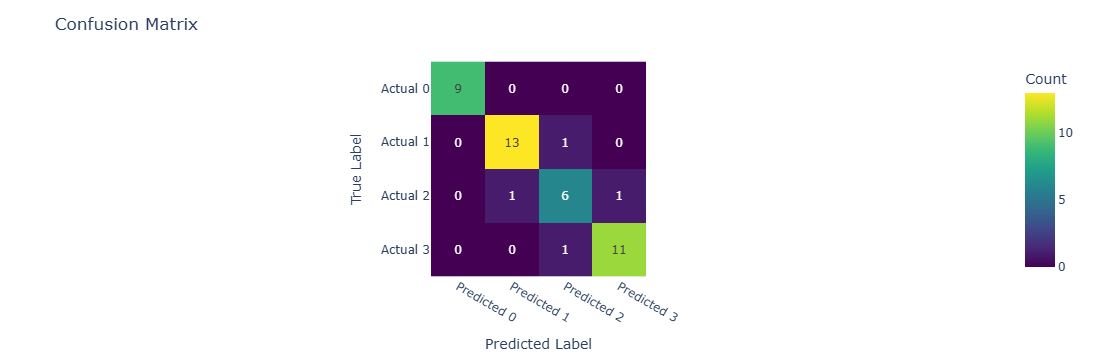

Beneficio neto para KNN: 108.4
Score train:  1.0
Score test:   0.9069767441860465

               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.93      0.93      0.93        14
           2       0.75      0.75      0.75         8
           3       0.92      0.92      0.92        12

    accuracy                           0.91        43
   macro avg       0.90      0.90      0.90        43
weighted avg       0.91      0.91      0.91        43



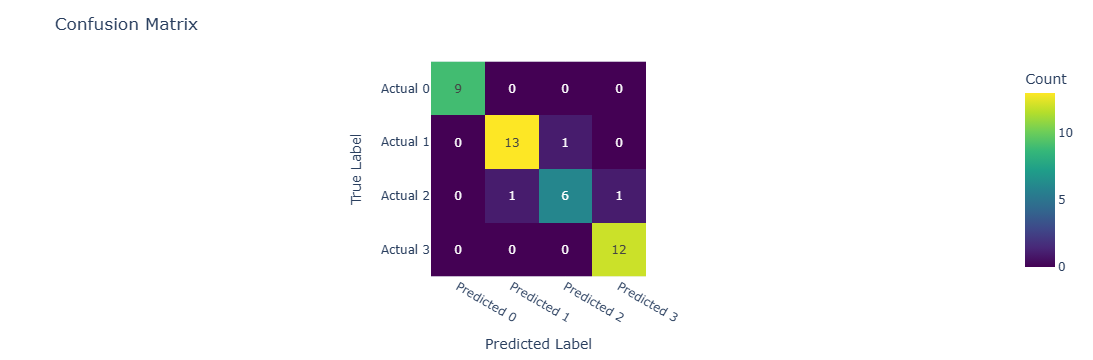

Beneficio neto para Decision Tree: 111.39999999999999
Score train:  1.0
Score test:   0.9302325581395349

               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.93      0.93      0.93        14
           2       0.86      0.75      0.80         8
           3       0.92      1.00      0.96        12

    accuracy                           0.93        43
   macro avg       0.93      0.92      0.92        43
weighted avg       0.93      0.93      0.93        43



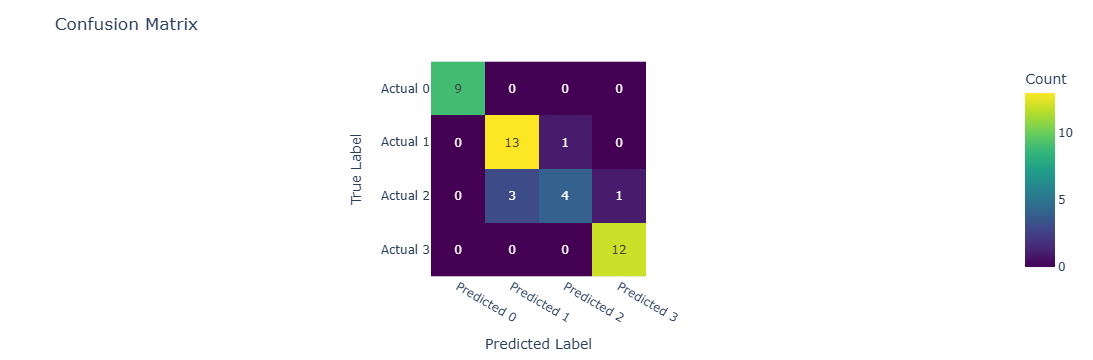

Beneficio neto para SVM: 105.4
Score train:  0.890625
Score test:   0.8837209302325582

               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.81      0.93      0.87        14
           2       0.80      0.50      0.62         8
           3       0.92      1.00      0.96        12

    accuracy                           0.88        43
   macro avg       0.88      0.86      0.86        43
weighted avg       0.88      0.88      0.87        43



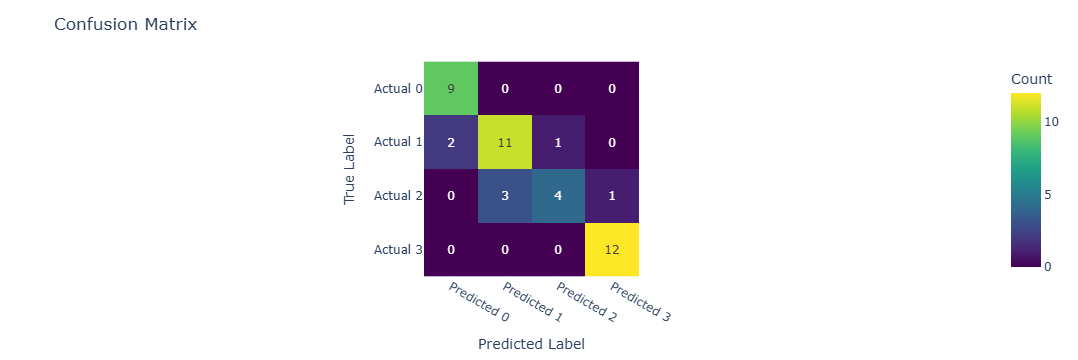

Beneficio neto para Naive Bayes: 99.39999999999999
Score train:  0.7578125
Score test:   0.8372093023255814

               precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       0.79      0.79      0.79        14
           2       0.80      0.50      0.62         8
           3       0.92      1.00      0.96        12

    accuracy                           0.84        43
   macro avg       0.83      0.82      0.82        43
weighted avg       0.83      0.84      0.83        43


El mejor modelo basado en el beneficio neto es: Decision Tree con un beneficio neto de 111.39999999999999


In [35]:
# Definimos los modelos clasificadores
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
svc = SVC()
nb = GaussianNB()

# Definimos los hiperparámetros a probar
param_grid_knn = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
param_grid_dt = {'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 10, 20]}
param_grid_svc = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
param_grid_nb = {'var_smoothing': [1e-9, 1e-8, 1e-7]}

# Usamos GridSearchCV para cada modelo
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy')
grid_svc = GridSearchCV(svc, param_grid_svc, cv=5, scoring='accuracy')
grid_nb = GridSearchCV(nb, param_grid_nb, cv=5, scoring='accuracy')

# Entrenamos y encontramos los mejores parámetros
grid_knn.fit(X_train, y_train)
grid_dt.fit(X_train, y_train)
grid_svc.fit(X_train, y_train)
grid_nb.fit(X_train, y_train)

# Obtener los mejores modelos
best_knn = grid_knn.best_estimator_
best_dt = grid_dt.best_estimator_
best_svc = grid_svc.best_estimator_
best_nb = grid_nb.best_estimator_

print(f"Mejores parametros de Vecinos cercanos: {best_knn}")
print(f"Mejores parametros de Árbol de decisión: {best_dt}")
print(f"Mejores parámetros de Máquina de soporte vectorial: {best_svc}")
print(f"Mejor modelo de Naive Bayes: {best_nb}""\n")

# Evaluamos los modelos en el conjunto de prueba
models = {'KNN': best_knn, 'Decision Tree': best_dt, 'SVM': best_svc, 'Naive Bayes': best_nb}

# Asignamos valores monetarios a los diferentes resultados
beneficio_vp = 1.0
costo_fp = 0.8
beneficio_vn = 0.6
costo_fn = 0.6

mejor_modelo = None
mejor_beneficio = float('-inf')

beneficios_netos = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    beneficio_neto = calcular_costo_beneficio(y_test, y_pred, costo_fp, costo_fn, beneficio_tp, beneficio_tn)
    beneficios_netos.append((name, beneficio_neto))
    print(f"Beneficio neto para {name}: {beneficio_neto}")
    print('Score train: ', model.score(X_train, y_train))
    print('Score test:  ', model.score(X_test, y_test))
    print("\n",classification_report(y_test, y_pred))

    if beneficio_neto > mejor_beneficio:
        mejor_beneficio = beneficio_neto
        mejor_modelo = name

print(f"\nEl mejor modelo basado en el beneficio neto es: {mejor_modelo} con un beneficio neto de {mejor_beneficio}")

# Crear un DataFrame con los beneficios netos
df_beneficios = pd.DataFrame(beneficios_netos, columns=['Modelo', 'Beneficio Neto'])


In [36]:
# 1. Calcular la precisión en el conjunto de entrenamiento de forma directa
train_acc_dt = best_dt.score(X_train, y_train)
train_acc_knn = best_knn.score(X_train, y_train)
train_acc_svc = best_svc.score(X_train, y_train)
train_acc_nb = best_nb.score(X_train, y_train)

# 2. Obtener la precisión media de la validación cruzada (usando los datos de la búsqueda)
cv_acc_media_dt = grid_dt.best_score_
cv_acc_media_knn = grid_knn.best_score_
cv_acc_media_svc = grid_svc.best_score_
cv_acc_media_nb = grid_nb.best_score_

# 3. Calcular la precisión en el conjunto de prueba (datos nuevos)
test_acc_dt = best_dt.score(X_test, y_test)
test_acc_knn = best_knn.score(X_test, y_test)
test_acc_svc = best_svc.score(X_test, y_test)
test_acc_nb = best_nb.score(X_test, y_test)

# Mostrar los resultados para validar el modelo
print(f"Precisión en Entrenamiento directo dt: {train_acc_dt:.4f}")
print(f"Precisión en Entrenamiento directo knn: {train_acc_knn:.4f}")
print(f"Precisión en Entrenamiento directo svc: {train_acc_svc:.4f}")
print(f"Precisión en Entrenamiento directo bn: {train_acc_nb:.4f}")
print(f"Precisión media en Validación Cruzada (CV=5) dt: {cv_acc_media_dt:.4f}")
print(f"Precisión media en Validación Cruzada (CV=5) knn: {cv_acc_media_knn:.4f}")
print(f"Precisión media en Validación Cruzada (CV=5) svc: {cv_acc_media_svc:.4f}")
print(f"Precisión media en Validación Cruzada (CV=5) nb: {cv_acc_media_nb:.4f}")
print(f"Precisión en el conjunto de Prueba dt: {test_acc_dt:.4f}")
print(f"Precisión en el conjunto de Prueba knn: {test_acc_knn:.4f}")
print(f"Precisión en el conjunto de Prueba svc: {test_acc_svc:.4f}")
print(f"Precisión en el conjunto de Prueba nb: {test_acc_nb:.4f}")

Precisión en Entrenamiento directo dt: 1.0000
Precisión en Entrenamiento directo knn: 1.0000
Precisión en Entrenamiento directo svc: 0.8906
Precisión en Entrenamiento directo bn: 0.7578
Precisión media en Validación Cruzada (CV=5) dt: 0.9145
Precisión media en Validación Cruzada (CV=5) knn: 0.8985
Precisión media en Validación Cruzada (CV=5) svc: 0.8591
Precisión media en Validación Cruzada (CV=5) nb: 0.7265
Precisión en el conjunto de Prueba dt: 0.9302
Precisión en el conjunto de Prueba knn: 0.9070
Precisión en el conjunto de Prueba svc: 0.8837
Precisión en el conjunto de Prueba nb: 0.8372


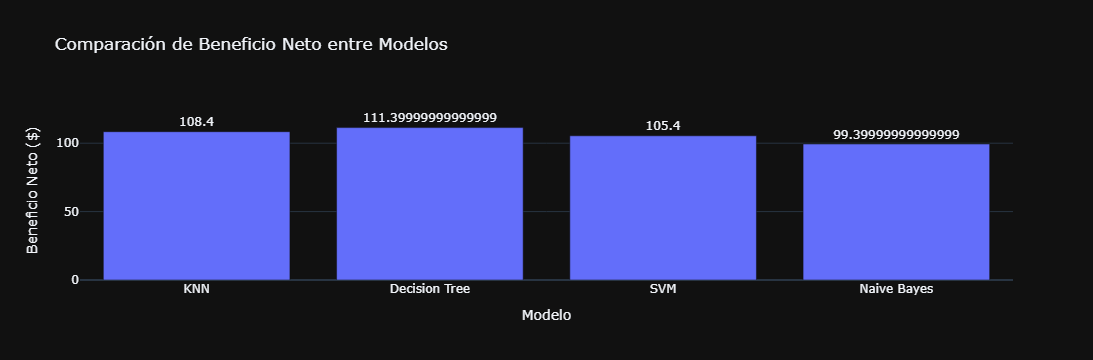

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\Comparación_beneficios_netos.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\Comparación_beneficios_netos.png


In [37]:
# Crear la gráfica de barras interactiva
fig = px.bar(df_beneficios, x='Modelo', y='Beneficio Neto', title='Beneficio Neto de Cada Modelo',
             labels={'Beneficio Neto': 'Beneficio Neto ($)', 'Modelo': 'Modelos'},
             template='plotly_dark', text='Beneficio Neto')

# Mostrar los valores en las barras
fig.update_traces(texttemplate='%{text}', textposition='outside')

# Mejorar la apariencia del gráfico
fig.update_layout(
    title='Comparación de Beneficio Neto entre Modelos',
    xaxis_title='Modelo',
    yaxis_title='Beneficio Neto ($)',
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

# Mostrar la gráfica
fig.show()
save_plotly_figure(
    fig,
    "Comparación_beneficios_netos"
)

Tras analizar el desempeño de los algoritmos de clasificación y contrastar sus métricas con el impacto financiero del negocio, se determinó que el Árbol de Decisión (Decision Tree) es la solución más robusta y rentable para predecir el nivel de espumado.A continuación, se fundamenta la selección mediante el comportamiento de cada modelo:

*  Árbol de Decisión (Decision Tree): Consolidó el mejor balance técnico y económico. Aunque exhibe un puntaje de entrenamiento perfecto ($1.0$) que inicialmente sugería riesgo de sobreajuste, el modelo demostró una alta capacidad de generalización al alcanzar la precisión más elevada en el conjunto de prueba ($93.02\%$). Adicionalmente, registró el beneficio neto más alto de la simulación ($111.39$), consolidándose como la opción óptima para mitigar pérdidas operativas.

* Máquinas de Soporte Vectorial (SVM): Presentó un comportamiento altamente consistente y estable entre ambos conjuntos de datos, con una precisión del $89.06\%$ en entrenamiento y $88.37\%$ en prueba. Estos valores confirman la ausencia de sobreajuste, posicionándolo como un modelo confiable, aunque con un retorno económico inferior al Árbol de Decisión.


* K-Nearest Neighbors (KNN): Al igual que el Árbol de Decisión, alcanzó un puntaje perfecto de $1.0$ en la fase de entrenamiento; sin embargo, no logró replicar ese nivel de efectividad en la validación con datos no vistos, lo que evidencia una tendencia al sobreajuste (memorización de datos) en comparación con el modelo seleccionado.

* Naive Bayes: Registró el desempeño más bajo de la comparativa, con una precisión de $72.66\%$ en el conjunto de entrenamiento y $79.07\%$ en el de prueba. Estos resultados indican que el algoritmo es demasiado simple para capturar la complejidad y las relaciones de las variables operativas en la línea de llenado.

Conclusión del análisis: El Árbol de Decisión se selecciona formalmente para el entorno de producción debido a su superioridad en la precisión de prueba ($93\%$) y su capacidad directa para maximizar el beneficio económico general del proceso industrial

In [38]:
print("\nGuardado automático en la carpeta models\n")

MODELS_PATH = PROJECT_ROOT / "models"

MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Guardar los objetos GridSearchCV completos
joblib.dump(grid_knn, MODELS_PATH / "grid_knn.pkl")
joblib.dump(grid_dt, MODELS_PATH / "grid_decision_tree.pkl")
joblib.dump(grid_svc, MODELS_PATH / "grid_svm.pkl")
joblib.dump(grid_nb, MODELS_PATH / "grid_naive_bayes.pkl")

print("✅ Objetos GridSearchCV guardados.")

# Guardar únicamente los mejores modelos encontrados
joblib.dump(best_knn, MODELS_PATH / "knn.pkl")
joblib.dump(best_dt, MODELS_PATH / "decision_tree.pkl")
joblib.dump(best_svc, MODELS_PATH / "svm.pkl")
joblib.dump(best_nb, MODELS_PATH / "naive_bayes.pkl")

print("✅ Mejores modelos guardados.")

best_models = {
    "KNN": best_knn,
    "Decision Tree": best_dt,
    "SVM": best_svc,
    "Naive Bayes": best_nb
}

joblib.dump(
    best_models[mejor_modelo],
    MODELS_PATH / "best_model.pkl"
)

print(f"✅ Modelo seleccionado: {mejor_modelo}")

with open(
    MODELS_PATH / "feature_names.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        list(X.columns),
        f,
        indent=4,
        ensure_ascii=False
    )
print("✅ Variables guardadas.")

metadata = {
    "project": "Foam Quality Prediction",
    "author": "Gonzalo Civita",
    "target": "Nivel de espumado",
    "optimization": "GridSearchCV",
    "cross_validation": 5,
    "selected_model": mejor_modelo,
    "models": {
        "KNN": {
            "best_params": grid_knn.best_params_,
            "best_score": float(grid_knn.best_score_)
        },
        "Decision Tree": {
            "best_params": grid_dt.best_params_,
            "best_score": float(grid_dt.best_score_)
        },
        "SVM": {
            "best_params": grid_svc.best_params_,
            "best_score": float(grid_svc.best_score_)
        },
        "Naive Bayes": {
            "best_params": grid_nb.best_params_,
            "best_score": float(grid_nb.best_score_)
        }
    },
    "features": list(X.columns)
    
}

with open(
    MODELS_PATH / "model_metadata.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✅ Metadata guardada.")

print("\nContenido de la carpeta models:\n")

for file in sorted(MODELS_PATH.iterdir()):
    print(file.name)

print("\nTamaño de modelos guardados:\n")

for file in (PROJECT_ROOT / "models").glob("*.pkl"):
    print(f"{file.name:30} {file.stat().st_size/1024:.2f} KB")

print("\nVerificando modelos guardados:\n")

for file in sorted((PROJECT_ROOT / "models").glob("*.pkl")):
    model = joblib.load(file)
    print(f"{file.name:<25} -> {type(model).__name__}")


Guardado automático en la carpeta models

✅ Objetos GridSearchCV guardados.
✅ Mejores modelos guardados.
✅ Modelo seleccionado: Decision Tree
✅ Variables guardadas.
✅ Metadata guardada.

Contenido de la carpeta models:

best_model.pkl
decision_tree.pkl
feature_names.json
grid_decision_tree.pkl
grid_knn.pkl
grid_naive_bayes.pkl
grid_svm.pkl
knn.pkl
model_metadata.json
naive_bayes.pkl
README.md
svm.pkl

Tamaño de modelos guardados:

best_model.pkl                 4.17 KB
decision_tree.pkl              4.17 KB
grid_decision_tree.pkl         7.39 KB
grid_knn.pkl                   19.03 KB
grid_naive_bayes.pkl           3.25 KB
grid_svm.pkl                   9.04 KB
knn.pkl                        16.27 KB
naive_bayes.pkl                1.18 KB
svm.pkl                        6.51 KB

Verificando modelos guardados:

best_model.pkl            -> DecisionTreeClassifier
decision_tree.pkl         -> DecisionTreeClassifier
grid_decision_tree.pkl    -> GridSearchCV
grid_knn.pkl              -> Gri

# 12. Impacto para el negocio





**Costos actuales y beneficios esperados al implementar el modelo de clasificación basado en predicciones.**

**Datos iniciales:**

*   Velocidad nominal: 24000 botellas por hora.
*   Velocidad promedio actual: 19621 botellas por hora.

*   Velocidad después: 23678 botellas por hora.
*   Precio de venta por botella: $1.


*   Costo de producción por botella: $0.60.

*   Costos fijos mensuales: $50000.


*   Horas de operación diarias: 8 horas.
*   Días de operación mensuales: 30 días.


*   Desperdicio antes: 10%.
*   Desperdicio después: 3%.

**Definición de KPIs**


*  Incremento de la velocidad de producció: 20%

*   Reducción de desperdicios: 60%


*   Incremento del beneficio económico neto: 25%


**Producción mensual:**


*   Antes: 19621 botellas/hora × 8 horas/día × 30 días/mes = 4709040 botellas.
*   Después: 23678 botellas/hora × 8 horas/día × 30 días/mes = 5682720 botellas.

**Ingresos mensuales:**

*   Antes: 4709040 botellas × $1/botella = $4709040.
*   Después: 5682720 botellas × $1/botella = $5682720.

**Costos mensuales**

*Costos variables*:

*   Antes: 4709040 botellas × $0.60/botella = $2825424.
*   Después: 5682720 botellas × $0.60/botella = $3409632.

*Costos de desperdicio:*

*   Antes: 10% de 4709040 botellas = 470904 botellas. Costos de desperdicio: 470904 botellas × $0.60/botella = $282542.4.
*   Después: 3% de 5682720 botellas = 170481.6 botellas. Costos de desperdicio: 170481.6 botellas × $0.60/botella = $102288.96.

*Costos totales:*


*   Antes: $2825424 (variables) + $282542.4 (desperdicio) + $50000 (fijos) = $3157966.2.
*   Después: $3409632 (variables) + $102288.96 (desperdicio) + $50000 (fijos) = $3561920.

**Beneficios netos mensuales**


*   Antes: $4709040 - $3157966.2 = $1551073.8.

*   Después: $5682720 - $3561920 = $2120800.

**Incremento en los beneficios netos**


*   Incremento: $2120800 - $1551073.8 = $569726.2.

**Entonces, la mejora en la velocidad de embotellado, combinada con la reducción del desperdicio gracias a los modelos de clasificación, incrementaría los beneficios netos en $569,726.2 mensuales.**

**A continuación vemos un gráfico de barras en donde detallamos las variables anteriores**



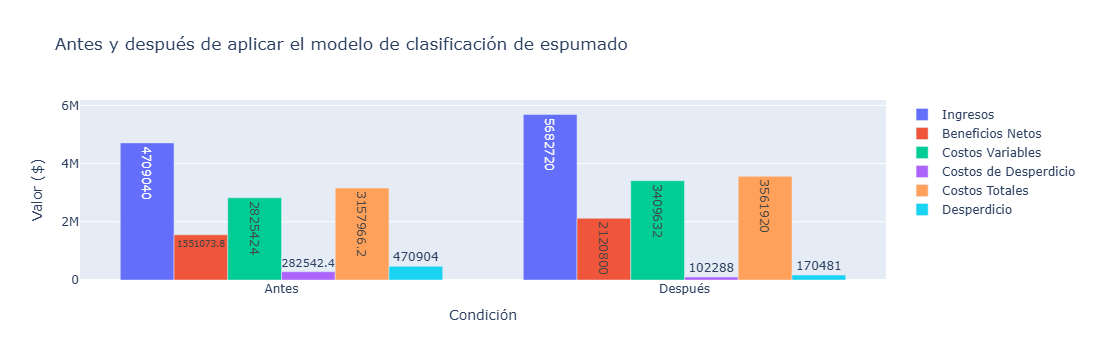

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\antes_despues_modelos.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\antes_despues_modelos.png


In [39]:
# Definición de los datos
categorias = ['Antes', 'Después']
ingresos = [4709040, 5682720]
beneficios_netos = [1551073.8, 2120800]
costos_variables = [2825424, 3409632]
costos_desperdicio = [282542.4, 102288]
costos_totales = [3157966.2, 3561920]
desperdicio = [470904, 170481]

# Creación de la figura
fig = go.Figure()

# Añadir barras para ingresos
fig.add_trace(go.Bar(x=categorias, y=ingresos,
                     name='Ingresos', text=ingresos, textposition='auto'))

# Añadir barras para beneficios netos
fig.add_trace(go.Bar(x=categorias, y=beneficios_netos,
                     name='Beneficios Netos', text=beneficios_netos, textposition='auto'))

# Añadir barras para costos variables
fig.add_trace(go.Bar(x=categorias, y=costos_variables,
                     name='Costos Variables', text=costos_variables, textposition='auto'))

# Añadir barras para costos de desperdicio
fig.add_trace(go.Bar(x=categorias, y=costos_desperdicio,
                     name='Costos de Desperdicio', text=costos_desperdicio, textposition='auto'))

# Añadir barras para costos totales
fig.add_trace(go.Bar(x=categorias, y=costos_totales,
                     name='Costos Totales', text=costos_totales, textposition='auto'))

# Añadir barras para desperdicio
fig.add_trace(go.Bar(x=categorias, y=desperdicio,
                     name='Desperdicio', text=desperdicio, textposition='auto'))

# Actualizar el diseño del gráfico
fig.update_layout(
    barmode='group',  # Agrupar las barras
    title='Antes y después de aplicar el modelo de clasificación de espumado',
    xaxis_title='Condición',
    yaxis_title='Valor ($)',
    yaxis=dict(range=[0, max(max(ingresos), max(beneficios_netos), max(costos_variables), max(costos_desperdicio), max(costos_totales), max(desperdicio)) + 500000]),
)

# Mostrar gráfico interactivo
fig.show()
save_plotly_figure(
    fig,
    "antes_despues_modelos"
)


Los KPIs a considerar:

Incremento de la velocidad de producción: 20.67%

Reducción de desperdicios: 70%

Incremento del beneficio económico neto: 36.73%


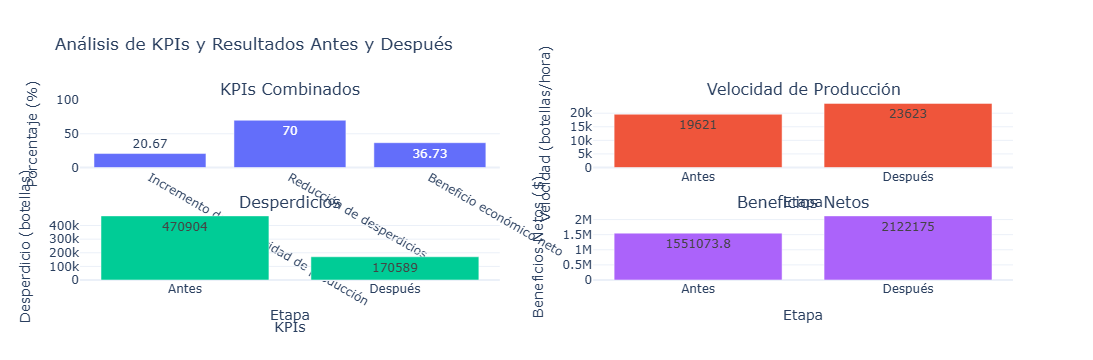

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\KPIs_antes_despues.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\KPIs_antes_despues.png


In [40]:
# Datos de los KPIs combinados
kpis = ['Incremento de la velocidad de producción', 'Reducción de desperdicios', 'Beneficio económico neto']
valores_kpis = [20.67, 70, 36.73]

# Datos antes y después
etapas = ['Antes', 'Después']
velocidad = [19621, 23623]
desperdicio = [470904, 170589]
beneficios_netos = [1551073.8, 2122175]

# Crear la figura con subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "KPIs Combinados",
        "Velocidad de Producción",
        "Desperdicios",
        "Beneficios Netos"
    ),
    specs=[[{"type": "bar"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "bar"}]]
)

# Agregar gráfico de KPIs combinados
fig.add_trace(go.Bar(x=kpis, y=valores_kpis, text=valores_kpis, textposition='auto'), row=1, col=1)

# Agregar gráfico de velocidad de producción
fig.add_trace(go.Bar(x=etapas, y=velocidad, text=velocidad, textposition='auto'), row=1, col=2)

# Agregar gráfico de desperdicios
fig.add_trace(go.Bar(x=etapas, y=desperdicio, text=desperdicio, textposition='auto'), row=2, col=1)

# Agregar gráfico de beneficios netos
fig.add_trace(go.Bar(x=etapas, y=beneficios_netos, text=beneficios_netos, textposition='auto'), row=2, col=2)

# Actualizar el diseño del gráfico
fig.update_layout(
    title_text="Análisis de KPIs y Resultados Antes y Después",
    showlegend=False,
    template='plotly_white'
)

# Actualizar ejes y títulos
fig.update_xaxes(title_text="KPIs", row=1, col=1)
fig.update_yaxes(title_text="Porcentaje (%)", row=1, col=1, range=[0, 100])

fig.update_xaxes(title_text="Etapa", row=1, col=2)
fig.update_yaxes(title_text="Velocidad (botellas/hora)", row=1, col=2)

fig.update_xaxes(title_text="Etapa", row=2, col=1)
fig.update_yaxes(title_text="Desperdicio (botellas)", row=2, col=1)

fig.update_xaxes(title_text="Etapa", row=2, col=2)
fig.update_yaxes(title_text="Beneficios Netos ($)", row=2, col=2)

# Mostrar el gráfico interactivo
fig.show()
save_plotly_figure(
    fig,
    "KPIs_antes_despues"
)



# 13. Simulación de escenario pasado

A continuación vemos una simulación de un escenario semanal antes y después de aplicar el modelo de clasificación basado en predicciones.

Datos recolectados:


* Cantidad de botellas producidas: 904400

* Velocidad de producció promedio: 19466 botellas/ hora

* Porcentaje de desperdicios: 1.66% (327 botellas + 50000 litros de bebida)


* Beneficio económico neto semanal: $346433

Después de aplicar el modelo con mejor rendimiento (Arbol de decisiones):


* Cantidad de botellas producidas: 1109892

* Velocidad de producció promedio: 23107 botellas/ hora

* Porcentaje de desperdicios: 0.67% (31 botellas + 25000 litros de bebida)


* Beneficio económico neto semanal: $436425.8

KPIs:

* Incremento de la velocidad de producció: 18.70%

* Reducción de desperdicios: 59.64%

* Incremento del beneficio económico neto: 25.97%









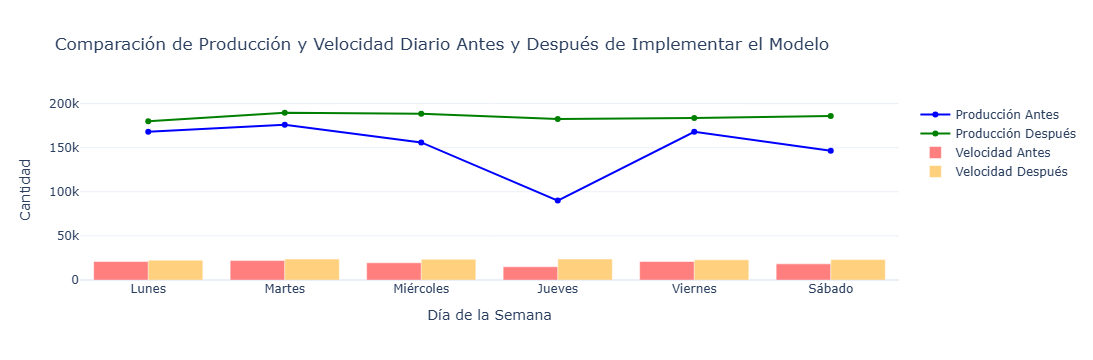

✅ HTML: C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\antes_despues_velocidad_produccion.html
✅ PNG : C:\Users\gonza\WorkSpace\DataScience-Portfolio\project-001-foam-quality-prediction\reports\figures\antes_despues_velocidad_produccion.png


In [41]:

dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado']
produccion_antes = [168000, 176000, 156000, 90000, 168000, 146400]
produccion_despues = [180000, 189600, 188440, 182400, 183584, 185928]

velocidad_antes = [21000, 22000, 19500, 15000, 21000, 18300]
velocidad_despues = [22500, 23700, 23555, 23800, 22948, 23141]

# Crear el gráfico de líneas para la producción
fig = go.Figure()

fig.add_trace(go.Scatter(x=dias_semana, y=produccion_antes,
                         mode='lines+markers',
                         name='Producción Antes',
                         line=dict(color='blue')))

fig.add_trace(go.Scatter(x=dias_semana, y=produccion_despues,
                         mode='lines+markers',
                         name='Producción Después',
                         line=dict(color='green')))

# Crear el gráfico de barras para el velocidad
fig.add_trace(go.Bar(x=dias_semana, y=velocidad_antes,
                     name='Velocidad Antes',
                     marker_color='red',
                     opacity=0.5))

fig.add_trace(go.Bar(x=dias_semana, y=velocidad_despues,
                     name='Velocidad Después',
                     marker_color='orange',
                     opacity=0.5))

# Actualizar el diseño del gráfico
fig.update_layout(
    title='Comparación de Producción y Velocidad Diario Antes y Después de Implementar el Modelo',
    xaxis_title='Día de la Semana',
    yaxis_title='Cantidad',
    barmode='group',  # Agrupar barras
    template='plotly_white'
)

# Mostrar el gráfico
fig.show()
save_plotly_figure(
    fig,
    "antes_despues_velocidad_produccion"
)


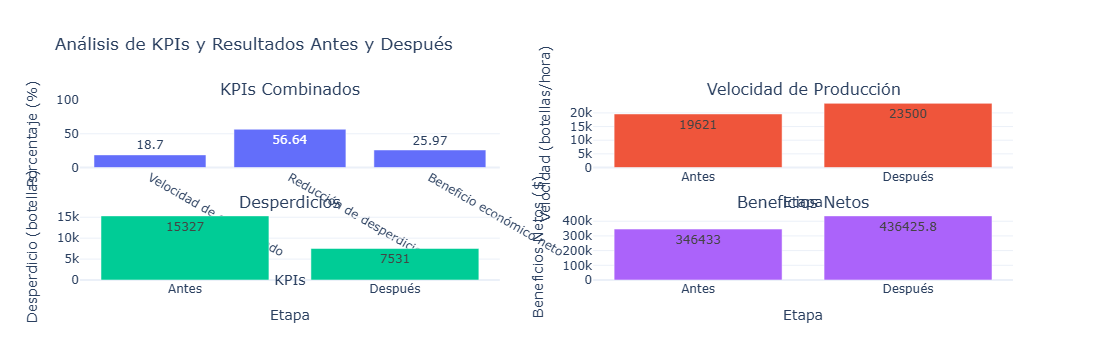

In [42]:
# Datos de los KPIs combinados
kpis = ['Velocidad de embotellado', 'Reducción de desperdicios', 'Beneficio económico neto']
valores_kpis = [18.70, 56.64, 25.97]

# Datos antes y después
etapas = ['Antes', 'Después']
velocidad = [19621, 23500]
desperdicio = [15327, 7531]
beneficios_netos = [346433, 436425.8]

# Crear la figura con subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "KPIs Combinados",
        "Velocidad de Producción",
        "Desperdicios",
        "Beneficios Netos"
    ),
    specs=[[{"type": "bar"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "bar"}]]
)

# Agregar gráfico de KPIs combinados
fig.add_trace(go.Bar(x=kpis, y=valores_kpis, text=valores_kpis, textposition='auto'), row=1, col=1)

# Agregar gráfico de velocidad de producción
fig.add_trace(go.Bar(x=etapas, y=velocidad, text=velocidad, textposition='auto'), row=1, col=2)

# Agregar gráfico de desperdicios
fig.add_trace(go.Bar(x=etapas, y=desperdicio, text=desperdicio, textposition='auto'), row=2, col=1)

# Agregar gráfico de beneficios netos
fig.add_trace(go.Bar(x=etapas, y=beneficios_netos, text=beneficios_netos, textposition='auto'), row=2, col=2)

# Actualizar el diseño del gráfico
fig.update_layout(
    title_text="Análisis de KPIs y Resultados Antes y Después",
    showlegend=False,
    template='plotly_white'
)

# Actualizar ejes y títulos
fig.update_xaxes(title_text="KPIs", row=1, col=1)
fig.update_yaxes(title_text="Porcentaje (%)", row=1, col=1, range=[0, 100])

fig.update_xaxes(title_text="Etapa", row=1, col=2)
fig.update_yaxes(title_text="Velocidad (botellas/hora)", row=1, col=2)

fig.update_xaxes(title_text="Etapa", row=2, col=1)
fig.update_yaxes(title_text="Desperdicio (botellas)", row=2, col=1)

fig.update_xaxes(title_text="Etapa", row=2, col=2)
fig.update_yaxes(title_text="Beneficios Netos ($)", row=2, col=2)

# Mostrar el gráfico interactivo
fig.show()

# 14. Conclusión

Este proyecto ha demostrado el potencial de las técnicas de clasificación para optimizar el proceso de embotellado de bebidas gaseosas, con importantes implicaciones económicas y operativas. La implementación de modelos de clasificación adecuados y la mejora continua de los procesos y datos pueden llevar a una mayor eficiencia, reducción de costos y mejora en la calidad del producto final.

### Implicaciones económicas
Los modelos desarrollados para la predicción y clasificación en este proyecto tienen implicaciones económicas significativas, especialmente en términos de optimización de la producción y reducción de costos. Aquí se destacan algunos puntos clave:

### Optimización de Producción
Los modelos de clasificación y regresión pueden predecir con precisión la velocidad de llenado y el nivel de espumado. Esto permite ajustar los parámetros de la producción en tiempo real, asegurando una operación más eficiente y minimizando los desperdicios.

### Reducción de Costos
La capacidad de predecir y ajustar la producción puede reducir los costos operativos. Por ejemplo, un mejor control del nivel de espumado puede evitar la pérdida de producto, lo que directamente afecta el costo de producción y el beneficio neto.

### Incremento de Beneficio Neto
El análisis muestra que el modelo de Árbol de Decisión proporciona el mayor beneficio neto (111.39), seguido por KNN (108.4), SVM (105.4) y Naive Bayes (93.4). Esto sugiere que una implementación basada en el modelo de Árbol de Decisión podría ser económicamente más ventajosa para la empresa.

### Importancia de la calidad de los datos
La precisión de los modelos de clasificación depende en gran medida de la calidad y cantidad de datos disponibles. Datos precisos y bien etiquetados permiten entrenar modelos más eficientes y confiables.


### Elección del modelo
Diferentes modelos tienen distintas ventajas y desventajas. Aunque el Árbol de Decisiones mostró inicialmente un alto rendimiento, el ajuste de parámetros y la prevención del sobreentrenamiento hicieron que su rendimiento y su beneficio neto sean aún mayor.

### Optimización de parámetros
El uso de GridSearchCV y otras técnicas de optimización de hiperparámetros es crucial para encontrar la configuración óptima para cada modelo, mejorando así su rendimiento y aplicabilidad.

### Influencia de variables clave
Identificamos que la temperatura de la bebida, el volumen de CO2 y el aire disuelto son variables críticas para controlar el espumado. La correcta gestión de estas variables puede mejorar significativamente la eficiencia del proceso de embotellado.





# 15. Próximos pasos

### Mejora continua de los datos
Mantener y mejorar la calidad de los datos mediante la implementación de sensores más precisos y el registro constante de las variables del proceso.

### Automatización del control de calidad
Implementar sistemas automatizados para monitorear y ajustar en tiempo real las variables críticas del proceso, como la temperatura y el volumen de CO2, para mantenerlos dentro de los rangos óptimos.

### Capacitación del personal
Proporcionar formación continua al personal para que comprendan la importancia de las variables clave y cómo gestionarlas adecuadamente.

### Análisis en tiempo real
Desarrollar sistemas de análisis en tiempo real que permitan una respuesta inmediata a cualquier desviación en las variables críticas, minimizando así el riesgo de espumado excesivo y otros problemas de calidad.

# Zona de prueba

In [ ]:


# Creamos una función que nos permita ingresar valores para las características
# y clasificar los datos basados en las predicciones de los modelos
# Solicitar al usuario que ingrese varios valores numéricos necesarios para la
# clasificación
def ingresar_valores_y_clasificar_todos():
    try:
        O2_ingreso = float(input("Ingrese el valor de O2 disuelto en el ingreso del Carbonatador "))
        Seteo_CO2 = float(input("Ingrese valor de seteo de CO2 "))
        Volumen_CO2 = float(input("Ingrese el valor del volumen de CO2 "))
        temp_botella = float(input("Ingrese la temperatura de carbonatación de la botella: "))
        temp_carbo = float(input("Ingrese la temperatura de carbonatación del Carbonatador "))
        sin_azucar = int(input("Ingrese 1 si la bebida es sin azucar, de lo contrario 0: "))
        print("\n")

        # Crear un array numpy con los valores ingresados
        valores_ingresados = np.array([[O2_ingreso, Seteo_CO2, Volumen_CO2, temp_botella,
                                        temp_carbo, sin_azucar ]])
        # Escalar los valores ingresados usando el scaler previamente ajustado
        valores_escalados = scaler.transform(valores_ingresados)
        # Definir un diccionario con los modelos de clasificación entrenados
        modelos = {
            'Árbol de Decisión': best_dt,
            'Árbol podado': arbol_alfa,
            'KNN': best_knn,
            'Máquina de Soporte Vectorial': best_svc,
            'Naive Bayes': best_nb
        }
        # Definir una función para traducir el nivel de espumado a texto
        def traducir_nivel_espumado(nivel):
            if nivel == 0:
                return "Sin espumado"
            elif nivel == 1:
                return "Espumado bajo"
            elif nivel == 2:
                return "Espumado medio"
            elif nivel == 3:
                return "Espumado alto"
            else:
                return "Desconocido"

        # Recorrer los modelos y realizar las predicciones
        for nombre_modelo, modelo in modelos.items():
            # Si el modelo es el árbol podado, usar valores no escalados
            if nombre_modelo == 'Árbol podado':
                prediccion = arbol_alfa.predict(valores_ingresados)
            # Para los demás modelos, usar los valores escalados
            else:
                    prediccion = modelo.predict(valores_escalados)
            # Traducir el nivel de espumado a texto
            nivel_espumado = traducir_nivel_espumado(prediccion[0])
            # Imprimir la predicción para el modelo actual
            print(f"El nivel de espumado predicho por {nombre_modelo} es: {nivel_espumado}")
            # Imprimir la predicción para el modelo actual
            print(f"El nivel de espumado predicho por {nombre_modelo} es: {prediccion[0]}")



    except ValueError:
        # Manejar el caso en que los valores ingresados no sean numéricos
        print("Por favor, ingrese valores numéricos válidos.")

    # Imprimir los valores ingresados y los valores escalados
    print("\nValores ingresados: ",valores_ingresados)
    print("Valores escalados: ",valores_escalados)

# Llamar a la función para ejecutar el proceso de ingreso de valores y
# clasificación
ingresar_valores_y_clasificar_todos()

Ingrese el valor de O2 disuelto en el ingreso del Carbonatador  0.3
Ingrese valor de seteo de CO2  0.8


# ¡Muchas Gracias!